# Modelo Final: Deteccion Jerarquica de Clones de Codigo

## Objetivo
Este notebook clasifica pares de programas Python mediante un pipeline facil de explicar:

1. **Type I** se identifica con comparacion deterministica de codigo normalizado; no usa Random Forest.
2. **Type II** se decide con atributos de similitud lexica tipo **Baker** y un **Random Forest**.
3. **Type III / Type IV** se separan con un segundo **Random Forest** que combina Baker y analisis estructural **AST**; se conservan las extensiones de flujo, IR simbolica y complejidad del modelo actual.

El notebook parte de `Modelo_Actual_Capa1_Lexica.ipynb`: se reorganiza y documenta, no se sustituye el algoritmo por otra tecnologia.


## Organizacion del dataset

La carpeta utilizada es `DataBaseProject/pares_clones/` y contiene cuatro subcarpetas: `T1`, `T2`, `T3` y `T4`. Cada archivo `.py` almacena **dos snippets** separados por saltos de linea; esos dos fragmentos forman una instancia a clasificar.

| Carpeta | Clase del modelo | Interpretacion |
|---|---|---|
| `T1` | `type_I` | Copia igual salvo limpieza superficial, por ejemplo comentarios o espacios. |
| `T2` | `type_II` | Misma estructura lexica con cambios de nombres o literales. |
| `T3` | `type_III` | Modificaciones estructurales parciales: sentencias agregadas, removidas o reorganizadas. |
| `T4` | `type_IV` | Soluciones semanticamente relacionadas, pero con mayor diferencia de implementacion. |

El numero del archivo se recupera como `problem_id`. La division train/validacion/test se hace por ese identificador para impedir que variantes del mismo problema aparezcan tanto en entrenamiento como en evaluacion.


## Criterio de presentacion y relacion con trabajos anteriores

Se replica el patron observable en los notebooks `KMeans`, `Jerarquico`, `Codigo1`, `Codigo2`, `Codigo3` y `Codigo4`: cargar datos, mostrar distribucion, definir el algoritmo, entrenar, predecir y reportar metricas con tablas y graficas.

El AST se inspira en `analisis.py` y `arbol.py`: aquellos archivos construyen nodos y usan un `Visitor` para emitir LLVM IR (`.ll`). Aqui no se compila ni se ejecuta LLVM; el mismo principio de recorrido se usa para convertir cada programa Python en caracteristicas comparables para Random Forest.


## Diseno experimental general

Este notebook documenta el experimento de Machine Learning, no solo el algoritmo.

**Unidad experimental:** cada fila es un par de snippets Python (`code_a`, `code_b`) con etiqueta real.

**Variable objetivo:** tipo de clon: `type_I`, `type_II`, `type_III` o `type_IV`.

**Conjuntos:** `train` ajusta modelos, `val` selecciona configuraciones y `test` confirma el resultado final. El split se hace por `problem_id` para evitar fuga de informacion.

**Metrica principal:** `accuracy`, porque el dataset esta balanceado.

**Metrica secundaria:** `F1 macro`, para verificar equilibrio entre clases.

**Modelo base:** Type I deterministico, RF2 con Baker y RF3 con Baker + AST + flujo + IR + complejidad.

**Regla de decision:** se elige por accuracy de validacion; F1 macro resuelve empates. Test se usa solo como confirmacion final.


## 1) Librerias y configuracion

**Que se hace:** importar herramientas estandar para datos, AST, Random Forest, metricas y graficas.

**Salida esperada:** rutas del dataset y semilla fija, necesarias para reproducir resultados.


In [1]:
# Bloque: importacion de librerias y rutas reproducibles.
# Las instrucciones siguientes conservan la logica funcional del modelo actual.
# Librerias base
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Any

import ast
import io
import json
import keyword
import random
import re
import time
import tokenize
import warnings
from difflib import SequenceMatcher

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore", category=SyntaxWarning)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

RUTA_BASE = Path.cwd()
RUTA_DATASET = RUTA_BASE / "DataBaseProject" if (RUTA_BASE / "DataBaseProject").exists() else RUTA_BASE
RUTA_PARES = RUTA_DATASET / "pares_clones"
print("SEED:", SEED)
print("RUTA_DATASET:", RUTA_DATASET)
print("RUTA_PARES:", RUTA_PARES)


SEED: 42
RUTA_DATASET: C:\Users\estef\Downloads\code-clone-detector\DataBaseProject
RUTA_PARES: C:\Users\estef\Downloads\code-clone-detector\DataBaseProject\pares_clones


In [2]:
# Bloque: constantes, umbrales y variables Baker base.
# Las instrucciones siguientes conservan la logica funcional del modelo actual.
# Configuracion global del experimento
# Las carpetas T1-T4 son la etiqueta conocida de cada par en el dataset.
TIPOS_CLON = ["T1", "T2", "T3", "T4"]
TIPO_A_CLASE = {"T1": "type_I", "T2": "type_II", "T3": "type_III", "T4": "type_IV"}
TIPO_A_GRUPO = {"T1": "pares_t1", "T2": "pares_t2", "T3": "pares_t3", "T4": "pares_t4"}

PATRON_SEPARADOR_SNIPPETS = re.compile(r"\n\s*\n\s*\n+")
PATRON_ESPACIOS = re.compile(r"[ \t]+")
PATRON_SALTOS = re.compile(r"\n{3,}")
PATRON_FILE_ID = re.compile(r"_(\d+)\.py$")

# Type I exige igualdad; Type II utiliza probabilidad del RF2 para pasar a la siguiente capa.
UMBRAL_TIPO_I = 1.0
UMBRAL_PROB_TIPO_II = 0.50
MIN_MATCH_LEN_BAKER = 3
AST_VARIANT_OFICIAL = "reduced"
ESTRATEGIA_BALANCEO = "undersample"

ETIQUETAS_MODELO = ["type_I", "type_II", "type_III", "type_IV"]

# El RF de Type II solo observa las ocho variables Baker base.
BAKER_FEATURES_BASE = [
    "baker_match_total_ratio",
    "baker_match_max_ratio",
    "baker_num_blocks",
    "baker_sequence_ratio",
    "baker_edit_distance_norm",
    "baker_token_jaccard",
    "baker_common_token_coverage",
    "baker_len_diff_rel",
]


## 2) Reconstruccion de los pares

**Que se hace:** recorrer carpetas `T1` a `T4`, separar los dos snippets de cada archivo y construir `DatosPares`.

**Por que:** los clasificadores necesitan una tabla donde cada fila tenga `code_a`, `code_b` y la clase real.

**Salida esperada:** total de pares, problemas unicos y distribucion balanceada por clase.


In [3]:
# Bloque: lectura de carpetas y reconstruccion del dataset.
# Las instrucciones siguientes conservan la logica funcional del modelo actual.
# Funcion: Divide cada archivo en los dos programas que forman el par a comparar.
def separar_snippets(texto_archivo: str) -> list[str]:
    texto = texto_archivo.replace("\r\n", "\n").replace("\r", "\n").strip()
    # Atiende un caso especial o decide la rama apropiada del algoritmo.
    if not texto:
        return []
    return [p.strip() for p in PATRON_SEPARADOR_SNIPPETS.split(texto) if p.strip()]


# Funcion: Recorre T1, T2, T3 y T4 y reconstruye la tabla de pares etiquetados.
def cargar_pares_desde_carpetas(ruta_pares: Path) -> pd.DataFrame:
    filas = []
    # Recorre los elementos para acumular la salida correspondiente de este paso.
    for tipo in TIPOS_CLON:
        carpeta = ruta_pares / tipo
        # Atiende un caso especial o decide la rama apropiada del algoritmo.
        if not carpeta.exists():
            raise FileNotFoundError(f"No existe carpeta esperada: {carpeta}")

        # Recorre los elementos para acumular la salida correspondiente de este paso.
        for archivo in sorted(carpeta.glob("*.py")):
            contenido = archivo.read_text(encoding="utf-8", errors="replace")
            snippets = separar_snippets(contenido)
            # Atiende un caso especial o decide la rama apropiada del algoritmo.
            if len(snippets) < 2:
                continue

            m = PATRON_FILE_ID.search(archivo.name)
            # Atiende un caso especial o decide la rama apropiada del algoritmo.
            if not m:
                continue

            problem_id = int(m.group(1))
            filas.append(
                {
                    "is_clone": 1,
                    "clone_type": TIPO_A_CLASE[tipo],
                    "source_group": TIPO_A_GRUPO[tipo],
                    "filename": archivo.name,
                    "file_path": str(archivo.relative_to(RUTA_DATASET)).replace("/", "\\"),
                    "problem_id": problem_id,
                    "snippet_index_a": 0,
                    "snippet_index_b": 1,
                    "code_a": snippets[0],
                    "code_b": snippets[1],
                }
            )

    # Atiende un caso especial o decide la rama apropiada del algoritmo.
    if not filas:
        raise RuntimeError("No se pudieron reconstruir pares desde carpetas.")

    return pd.DataFrame(filas)


DatosPares = cargar_pares_desde_carpetas(RUTA_PARES)
print("Filas reconstruidas:", len(DatosPares))
print("Problemas unicos:", DatosPares["problem_id"].nunique())
print("Distribucion por clase:")
print(DatosPares["clone_type"].value_counts().to_string())


Filas reconstruidas: 8400
Problemas unicos: 2100
Distribucion por clase:
clone_type
type_I      2100
type_II     2100
type_III    2100
type_IV     2100


## 2.1) Balance general del dataset

**Que se va a hacer:** contar cuantos pares existen en cada tipo de clon.

**Datos usados:** `DatosPares`, la tabla reconstruida desde las carpetas `T1`, `T2`, `T3` y `T4`.

**Salida esperada:** una tabla y una grafica de barras. Esta grafica justifica usar `accuracy` como metrica principal porque permite verificar si las clases estan balanceadas.


Balance general del dataset:


,clone_type,num_pares,porcentaje
0,type_I,2100,0.25
1,type_II,2100,0.25
2,type_III,2100,0.25
3,type_IV,2100,0.25


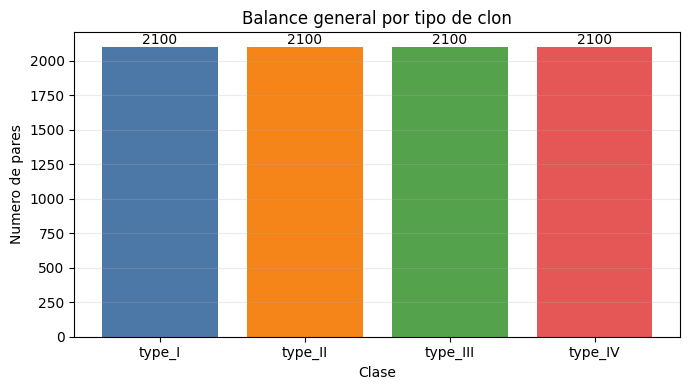

In [4]:

# Orden fijo de clases para que las tablas y graficas siempre se lean igual.
OrdenClases = ETIQUETAS_MODELO

# Conteo total por clase: una fila del dataset equivale a un par de codigos.
BalanceGeneral = (
    DatosPares["clone_type"]
    .value_counts()
    .reindex(OrdenClases)
    .rename_axis("clone_type")
    .reset_index(name="num_pares")
)

# Porcentaje por clase para explicar si el dataset esta balanceado.
BalanceGeneral["porcentaje"] = BalanceGeneral["num_pares"] / BalanceGeneral["num_pares"].sum()
print("Balance general del dataset:")
display(BalanceGeneral)

# Grafica no decorativa: muestra directamente la cantidad de ejemplos por clase.
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(BalanceGeneral["clone_type"], BalanceGeneral["num_pares"], color=["#4c78a8", "#f58518", "#54a24b", "#e45756"])
ax.set_title("Balance general por tipo de clon")
ax.set_xlabel("Clase")
ax.set_ylabel("Numero de pares")
ax.grid(axis="y", alpha=0.25)
for posicion, valor in enumerate(BalanceGeneral["num_pares"]):
    ax.text(posicion, valor, str(int(valor)), ha="center", va="bottom")
plt.tight_layout()
plt.show()


## 3) Limpieza y regla deterministica Type I

**Que se hace:** eliminar comentarios, normalizar espacios, tokenizar y formar una firma canonica.

**Por que:** Type I representa copia practicamente exacta; compararla con una regla es mas transparente que entrenar un modelo para algo determinista.

**Salida esperada:** columnas limpias y firmas para cada lado del par.


In [5]:
# Bloque: preprocesamiento lexico y firmas Type I.
# Las instrucciones siguientes conservan la logica funcional del modelo actual.
# Funcion: Retira comentarios para que Type I compare codigo y no anotaciones.
def quitar_comentarios(codigo: str) -> str:
    lineas = codigo.expandtabs(4).splitlines()
    limpias = []
    # Recorre los elementos para acumular la salida correspondiente de este paso.
    for ln in lineas:
        limpias.append(ln.split("#", 1)[0])
    return "\n".join(limpias)


# Funcion: Uniforma espacios y saltos sin modificar la estructura esencial.
def normalizar_espacios(codigo: str) -> str:
    lineas = [PATRON_ESPACIOS.sub(" ", l).rstrip() for l in codigo.splitlines()]
    normalizado = "\n".join(lineas).strip()
    return PATRON_SALTOS.sub("\n\n", normalizado)


# Funcion: Aplica la limpieza comun usada antes de extraer atributos.
def preprocesar_codigo(codigo: str) -> str:
    return normalizar_espacios(quitar_comentarios(codigo))


# Funcion: Convierte codigo limpio en tokens simples para inspeccion.
def tokenizar_python_basico(codigo: str) -> list[str]:
    patron = r"[A-Za-z_]\w*|\d+|==|!=|<=|>=|[][(){}.,:;+*/%=<>-]"
    return re.findall(patron, codigo)

# Funcion: Construye la firma exacta que decide Type I sin clasificador.
def firma_tipo_i_canonica(codigo: str) -> str:
    codigo_ok = preprocesar_codigo(codigo)
    return re.sub(r"\s+", "", codigo_ok)


DatosPares = DatosPares.copy()
DatosPares["code_a_clean"] = DatosPares["code_a"].map(preprocesar_codigo)
DatosPares["code_b_clean"] = DatosPares["code_b"].map(preprocesar_codigo)
DatosPares["tokens_a"] = DatosPares["code_a_clean"].map(tokenizar_python_basico)
DatosPares["tokens_b"] = DatosPares["code_b_clean"].map(tokenizar_python_basico)
DatosPares["token_text_a"] = DatosPares["tokens_a"].map(lambda t: " ".join(t))
DatosPares["token_text_b"] = DatosPares["tokens_b"].map(lambda t: " ".join(t))
DatosPares["type1_signature_a"] = DatosPares["code_a_clean"].map(firma_tipo_i_canonica)
DatosPares["type1_signature_b"] = DatosPares["code_b_clean"].map(firma_tipo_i_canonica)

print("Columnas disponibles:", len(DatosPares.columns))


Columnas disponibles: 18


## 4) Division de conjuntos por problema

**Que se hace:** dividir por `problem_id` en entrenamiento, validacion y prueba.

**Por que:** dividir filas al azar produciria fuga de informacion si el mismo ejercicio aparece en varios conjuntos.

**Salida esperada:** tabla de distribuciones por `split` y clase.


In [6]:
# Bloque: split por grupo y balanceo controlado.
# Las instrucciones siguientes conservan la logica funcional del modelo actual.
# Funcion: Separa train, validacion y test sin filtrar un problema entre conjuntos.
def split_por_grupo(
    df: pd.DataFrame,
    group_col: str,
    target_col: str,
    seed: int = 42,
    train_size: float = 0.7,
    val_size: float = 0.15,
    test_size: float = 0.15,
):
    proporcion_temp = val_size + test_size
    proporcion_test_rel = test_size / proporcion_temp

    gss_train = GroupShuffleSplit(n_splits=1, train_size=train_size, random_state=seed)
    idx_train_np, idx_temp_np = next(gss_train.split(df, y=df[target_col], groups=df[group_col]))

    df_temp = df.iloc[idx_temp_np]
    gss_temp = GroupShuffleSplit(n_splits=1, test_size=proporcion_test_rel, random_state=seed)
    idx_val_rel, idx_test_rel = next(gss_temp.split(df_temp, y=df_temp[target_col], groups=df_temp[group_col]))

    return df.index[idx_train_np], df_temp.index[idx_val_rel], df_temp.index[idx_test_rel]


# Funcion: Marca cada fila con el conjunto al que fue asignada.
def asignar_split(df: pd.DataFrame, idx_train, idx_val, idx_test, col_split: str = "split") -> pd.DataFrame:
    datos = df.copy()
    datos[col_split] = "unassigned"
    datos.loc[idx_train, col_split] = "train"
    datos.loc[idx_val, col_split] = "val"
    datos.loc[idx_test, col_split] = "test"
    return datos


# Funcion: Resume cantidad de pares, problemas y clases por particion.
def estadisticas_split(df: pd.DataFrame, split_col: str, target_col: str, group_col: str) -> list[dict[str, Any]]:
    resumen = []
    # Recorre los elementos para acumular la salida correspondiente de este paso.
    for nombre_split, df_split in df.groupby(split_col):
        conteos = df_split[target_col].value_counts().to_dict()
        resumen.append(
            {
                "split": nombre_split,
                "rows": int(len(df_split)),
                "unique_groups": int(df_split[group_col].nunique()),
                "class_distribution": {str(k): int(v) for k, v in conteos.items()},
            }
        )
    return resumen


# Funcion: Balancea solo entrenamiento cuando la estrategia lo requiere.
def balancear_train(df_train: pd.DataFrame, target_col: str, estrategia: str = "none", seed: int = 42):
    conteos = df_train[target_col].value_counts()
    info = {
        "strategy": estrategia,
        "rows_before": int(len(df_train)),
        "class_distribution_before": {str(k): int(v) for k, v in conteos.items()},
    }

    # Atiende un caso especial o decide la rama apropiada del algoritmo.
    if estrategia == "none" or len(conteos) <= 1:
        info["rows_after"] = int(len(df_train))
        info["class_distribution_after"] = info["class_distribution_before"]
        return df_train.copy(), info

    # Atiende un caso especial o decide la rama apropiada del algoritmo.
    if estrategia == "undersample":
        n_obj = int(conteos.min())
        rep = False
    # Evalua la alternativa siguiente cuando la condicion previa no se cumplio.
    elif estrategia == "oversample":
        n_obj = int(conteos.max())
        rep = True
    # Conserva el caso restante cuando ninguna condicion anterior aplica.
    else:
        info["rows_after"] = int(len(df_train))
        info["class_distribution_after"] = info["class_distribution_before"]
        return df_train.copy(), info

    partes = []
    # Recorre los elementos para acumular la salida correspondiente de este paso.
    for clase in conteos.index.tolist():
        df_clase = df_train[df_train[target_col] == clase]
        partes.append(df_clase.sample(n=n_obj, replace=rep, random_state=seed))

    out = pd.concat(partes, axis=0).sample(frac=1.0, random_state=seed).copy()
    c2 = out[target_col].value_counts()
    info["rows_after"] = int(len(out))
    info["class_distribution_after"] = {str(k): int(v) for k, v in c2.items()}
    return out, info


idx_train, idx_val, idx_test = split_por_grupo(
    df=DatosPares,
    group_col="problem_id",
    target_col="clone_type",
    seed=SEED + 100,
    train_size=0.7,
    val_size=0.15,
    test_size=0.15,
)

DatosModelo = asignar_split(DatosPares, idx_train, idx_val, idx_test)

print("Estadisticas split:")
# Recorre los elementos para acumular la salida correspondiente de este paso.
for fila in estadisticas_split(DatosModelo, "split", "clone_type", "problem_id"):
    print(fila)


Estadisticas split:
{'split': 'test', 'rows': 1260, 'unique_groups': 315, 'class_distribution': {'type_I': 315, 'type_II': 315, 'type_III': 315, 'type_IV': 315}}
{'split': 'train', 'rows': 5880, 'unique_groups': 1470, 'class_distribution': {'type_I': 1470, 'type_II': 1470, 'type_III': 1470, 'type_IV': 1470}}
{'split': 'val', 'rows': 1260, 'unique_groups': 315, 'class_distribution': {'type_I': 315, 'type_II': 315, 'type_III': 315, 'type_IV': 315}}


## 4.1) Distribucion por split y clase

**Que se va a hacer:** revisar cuantos ejemplos de cada clase quedaron en `train`, `val` y `test`.

**Datos usados:** `DatosModelo`, despues de aplicar el split por `problem_id`.

**Salida esperada:** una tabla cruzada y una grafica agrupada. Esto confirma que el experimento compara modelos con particiones balanceadas y sin fuga de informacion.


Distribucion por split y clase:


clone_type,type_I,type_II,type_III,type_IV
split,,,,
train,1470,1470,1470,1470
val,315,315,315,315
test,315,315,315,315


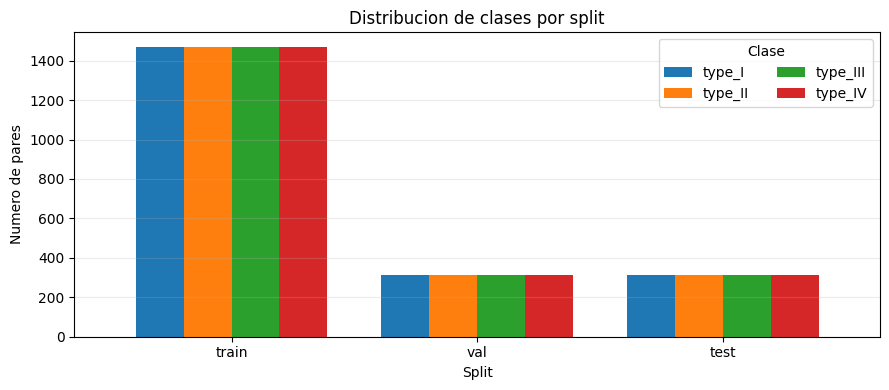

Problemas que aparecen en mas de un split: 0


In [7]:

# Tabla cruzada: filas = split, columnas = clase real.
DistribucionSplit = (
    DatosModelo
    .pivot_table(index="split", columns="clone_type", values="filename", aggfunc="count", fill_value=0)
    .reindex(index=["train", "val", "test"], columns=ETIQUETAS_MODELO)
)
print("Distribucion por split y clase:")
display(DistribucionSplit)

# Grafica agrupada para comparar visualmente si cada split mantiene el balance por clase.
fig, ax = plt.subplots(figsize=(9, 4))
DistribucionSplit.plot(kind="bar", ax=ax, width=0.78)
ax.set_title("Distribucion de clases por split")
ax.set_xlabel("Split")
ax.set_ylabel("Numero de pares")
ax.tick_params(axis="x", rotation=0)
ax.grid(axis="y", alpha=0.25)
ax.legend(title="Clase", ncol=2)
plt.tight_layout()
plt.show()

# Verificacion del criterio experimental: cada problem_id aparece en un solo split.
SplitPorProblema = DatosModelo.groupby("problem_id")["split"].nunique()
ProblemasConFuga = int((SplitPorProblema > 1).sum())
print("Problemas que aparecen en mas de un split:", ProblemasConFuga)


## 5) Caracteristicas Baker para Type II

**Que se hace:** generalizar tokens (`ID`, `NUM`, `STR`) y medir coincidencias, distancia de edicion, LCS y Jaccard.

**Por que:** Type II cambia nombres o literales, pero conserva una forma lexica similar. El RF2 usa solo las ocho features Baker base para mantener esta etapa interpretable.

**Salida esperada:** funciones capaces de convertir cualquier tabla de pares en variables numericas Baker.


In [8]:
# Bloque: extraccion de similitud Baker.
# Las instrucciones siguientes conservan la logica funcional del modelo actual.
# Funcion: Calcula distancia de edicion entre secuencias de tokens.
def _levenshtein_tokens(seq_a: list[str], seq_b: list[str]) -> int:
    n, m = len(seq_a), len(seq_b)
    # Atiende un caso especial o decide la rama apropiada del algoritmo.
    if n == 0:
        return m
    # Atiende un caso especial o decide la rama apropiada del algoritmo.
    if m == 0:
        return n

    prev = list(range(m + 1))
    # Recorre los elementos para acumular la salida correspondiente de este paso.
    for i in range(1, n + 1):
        curr = [i] + [0] * m
        ai = seq_a[i - 1]
        # Recorre los elementos para acumular la salida correspondiente de este paso.
        for j in range(1, m + 1):
            cost = 0 if ai == seq_b[j - 1] else 1
            curr[j] = min(prev[j] + 1, curr[j - 1] + 1, prev[j - 1] + cost)
        prev = curr
    return int(prev[m])


# Funcion: Calcula la subsecuencia comun mas larga entre tokens.
def _lcs_len_tokens(seq_a: list[str], seq_b: list[str]) -> int:
    # Atiende un caso especial o decide la rama apropiada del algoritmo.
    if not seq_a or not seq_b:
        return 0
    dp = [0] * (len(seq_b) + 1)
    # Recorre los elementos para acumular la salida correspondiente de este paso.
    for xa in seq_a:
        prev = 0
        # Recorre los elementos para acumular la salida correspondiente de este paso.
        for j, xb in enumerate(seq_b, start=1):
            temp = dp[j]
            # Atiende un caso especial o decide la rama apropiada del algoritmo.
            if xa == xb:
                dp[j] = prev + 1
            # Conserva el caso restante cuando ninguna condicion anterior aplica.
            else:
                dp[j] = max(dp[j], dp[j - 1])
            prev = temp
    return int(dp[-1])


# Funcion: Forma n-gramas de tokens generalizados para medir coincidencia local.
def _baker_ngram_set(tokens: list[str], n: int) -> set[tuple[str, ...]]:
    # Atiende un caso especial o decide la rama apropiada del algoritmo.
    if len(tokens) < n:
        return set()
    return {tuple(tokens[i : i + n]) for i in range(len(tokens) - n + 1)}


# Funcion: Mide el traslape normalizado de dos conjuntos.
def _jaccard_set(a: set[Any], b: set[Any]) -> float:
    # Atiende un caso especial o decide la rama apropiada del algoritmo.
    if not a and not b:
        return 1.0
    union = a | b
    return float(len(a & b) / len(union)) if union else 0.0


# Funcion: Generaliza identificadores y literales siguiendo la idea Baker.
def baker_tokenizar_generalizar(codigo: str) -> list[str]:
    codigo_ok = codigo.replace("\r\n", "\n").replace("\r", "\n").expandtabs(4)
    ignorar = {
        tokenize.NL,
        tokenize.NEWLINE,
        tokenize.INDENT,
        tokenize.DEDENT,
        tokenize.COMMENT,
        tokenize.ENCODING,
        tokenize.ENDMARKER,
    }
    out = []
    # Intenta el analisis estructurado antes de usar un respaldo seguro.
    try:
        flujo = tokenize.generate_tokens(io.StringIO(codigo_ok).readline)
        # Recorre los elementos para acumular la salida correspondiente de este paso.
        for tok in flujo:
            # Atiende un caso especial o decide la rama apropiada del algoritmo.
            if tok.type in ignorar:
                continue
            # Atiende un caso especial o decide la rama apropiada del algoritmo.
            if tok.type == tokenize.NAME:
                out.append(tok.string if keyword.iskeyword(tok.string) else "ID")
            # Evalua la alternativa siguiente cuando la condicion previa no se cumplio.
            elif tok.type == tokenize.NUMBER:
                out.append("NUM")
            # Evalua la alternativa siguiente cuando la condicion previa no se cumplio.
            elif tok.type == tokenize.STRING:
                out.append("STR")
            # Evalua la alternativa siguiente cuando la condicion previa no se cumplio.
            elif tok.type == tokenize.OP:
                out.append(tok.string)
            # Conserva el caso restante cuando ninguna condicion anterior aplica.
            else:
                out.append(tok.string)
    # Mantiene el pipeline operativo si el fragmento no se puede interpretar completamente.
    except Exception:
        tokens = re.findall(r"[A-Za-z_]\w*|\d+|==|!=|<=|>=|[\[\](){}.,:;+*/%=<>-]", codigo_ok)
        # Recorre los elementos para acumular la salida correspondiente de este paso.
        for t in tokens:
            # Atiende un caso especial o decide la rama apropiada del algoritmo.
            if re.fullmatch(r"[A-Za-z_]\w*", t):
                out.append(t if keyword.iskeyword(t) else "ID")
            # Evalua la alternativa siguiente cuando la condicion previa no se cumplio.
            elif re.fullmatch(r"\d+", t):
                out.append("NUM")
            # Conserva el caso restante cuando ninguna condicion anterior aplica.
            else:
                out.append(t)
    return out


# Funcion: Obtiene las similitudes lexicas Baker de un par de programas.
def baker_features_par(codigo_a: str, codigo_b: str, min_match_len: int = 3) -> dict[str, float]:
    ta = baker_tokenizar_generalizar(codigo_a)
    tb = baker_tokenizar_generalizar(codigo_b)

    # Atiende un caso especial o decide la rama apropiada del algoritmo.
    if len(ta) == 0 and len(tb) == 0:
        return {
            "baker_match_total_ratio": 1.0,
            "baker_match_max_ratio": 1.0,
            "baker_num_blocks": 1.0,
            "baker_sequence_ratio": 1.0,
            "baker_edit_distance_norm": 0.0,
            "baker_token_jaccard": 1.0,
            "baker_common_token_coverage": 1.0,
            "baker_len_diff_rel": 0.0,
            "baker_lcs_ratio": 1.0,
            "baker_bigram_jaccard": 1.0,
            "baker_trigram_jaccard": 1.0,
            "baker_keyword_overlap": 1.0,
            "baker_operator_overlap": 1.0,
            "baker_literal_density_diff": 0.0,
            "baker_identifier_density_diff": 0.0,
        }

    # Atiende un caso especial o decide la rama apropiada del algoritmo.
    if len(ta) == 0 or len(tb) == 0:
        return {
            "baker_match_total_ratio": 0.0,
            "baker_match_max_ratio": 0.0,
            "baker_num_blocks": 0.0,
            "baker_sequence_ratio": 0.0,
            "baker_edit_distance_norm": 1.0,
            "baker_token_jaccard": 0.0,
            "baker_common_token_coverage": 0.0,
            "baker_len_diff_rel": 1.0,
            "baker_lcs_ratio": 0.0,
            "baker_bigram_jaccard": 0.0,
            "baker_trigram_jaccard": 0.0,
            "baker_keyword_overlap": 0.0,
            "baker_operator_overlap": 0.0,
            "baker_literal_density_diff": 1.0,
            "baker_identifier_density_diff": 1.0,
        }

    matcher = SequenceMatcher(a=ta, b=tb, autojunk=False)
    blocks = [b for b in matcher.get_matching_blocks() if b.size >= min_match_len]
    total_match = float(sum(b.size for b in blocks))
    max_match = float(max([b.size for b in blocks], default=0.0))

    base_min = float(min(len(ta), len(tb)))
    base_max = float(max(len(ta), len(tb)))
    set_a, set_b = set(ta), set(tb)
    union = set_a | set_b
    inter = set_a & set_b

    edit_dist = float(_levenshtein_tokens(ta, tb))
    lcs_ratio = float(_lcs_len_tokens(ta, tb) / max(1.0, base_min))
    bigram_j = _jaccard_set(_baker_ngram_set(ta, 2), _baker_ngram_set(tb, 2))
    trigram_j = _jaccard_set(_baker_ngram_set(ta, 3), _baker_ngram_set(tb, 3))

    kw = set(keyword.kwlist)
    kw_a = {t for t in ta if t in kw}
    kw_b = {t for t in tb if t in kw}
    kw_overlap = _jaccard_set(kw_a, kw_b)

    op_pool = {
        "+",
        "-",
        "*",
        "/",
        "//",
        "%",
        "**",
        "=",
        "==",
        "!=",
        "<",
        ">",
        "<=",
        ">=",
        "+=",
        "-=",
        "*=",
        "/=",
        "%=",
        "and",
        "or",
        "not",
        "in",
        "is",
        "(",
        ")",
        "[",
        "]",
        "{",
        "}",
        ".",
        ",",
        ":",
    }
    op_a = {t for t in ta if t in op_pool}
    op_b = {t for t in tb if t in op_pool}
    op_overlap = _jaccard_set(op_a, op_b)

    lit_a = sum(1 for t in ta if t in {"NUM", "STR"}) / max(1.0, len(ta))
    lit_b = sum(1 for t in tb if t in {"NUM", "STR"}) / max(1.0, len(tb))
    id_a = sum(1 for t in ta if t == "ID") / max(1.0, len(ta))
    id_b = sum(1 for t in tb if t == "ID") / max(1.0, len(tb))

    return {
        "baker_match_total_ratio": total_match / base_min,
        "baker_match_max_ratio": max_match / base_min,
        "baker_num_blocks": float(len(blocks)),
        "baker_sequence_ratio": float(matcher.ratio()),
        "baker_edit_distance_norm": edit_dist / max(1.0, base_max),
        "baker_token_jaccard": float(len(inter) / len(union)) if len(union) > 0 else 0.0,
        "baker_common_token_coverage": float(len(inter) / max(1, min(len(set_a), len(set_b)))),
        "baker_len_diff_rel": abs(len(ta) - len(tb)) / max(1.0, base_max),
        "baker_lcs_ratio": lcs_ratio,
        "baker_bigram_jaccard": bigram_j,
        "baker_trigram_jaccard": trigram_j,
        "baker_keyword_overlap": kw_overlap,
        "baker_operator_overlap": op_overlap,
        "baker_literal_density_diff": abs(lit_a - lit_b),
        "baker_identifier_density_diff": abs(id_a - id_b),
    }


# Funcion: Construye la matriz Baker para todos los pares recibidos.
def construir_features_baker(df: pd.DataFrame, min_match_len: int = 3) -> pd.DataFrame:
    rows = [baker_features_par(a, b, min_match_len=min_match_len) for a, b in zip(df["code_a_clean"], df["code_b_clean"])]
    return pd.DataFrame(rows, index=df.index)


## 6) AST mediante Visitor

**Que se hace:** parsear cada snippet con `ast` de Python y recorrerlo con visitantes especializados.

**Por que:** igual que el Visitor de `arbol.py` permite generar LLVM en la practica anterior, aqui un Visitor separa el recorrido del arbol de las mediciones que se desean obtener.

**Salida esperada:** contadores estructurales, secuencias de flujo y una descripcion semantica ligera.


In [9]:
# Bloque: visitors AST para estructura, flujo y semantica ligera.
# Las instrucciones siguientes conservan la logica funcional del modelo actual.
# Funcion: Prepara fragmentos para que Python pueda formar un AST robustamente.
def _normalizar_codigo_para_ast(codigo: str) -> str:
    codigo = codigo.replace("\r\n", "\n").replace("\r", "\n").replace("\t", "    ").expandtabs(4)
    lineas = codigo.splitlines()
    out = []
    i = 0
    # Repite el proceso hasta consumir los elementos pendientes.
    while i < len(lineas):
        ln = lineas[i]
        s = ln.strip()
        indent_actual = len(ln) - len(ln.lstrip(" "))
        # Atiende un caso especial o decide la rama apropiada del algoritmo.
        if re.match(r"^(else\s*:|elif\b.*:|except\b.*:|finally\s*:)$", s):
            ln = " " * indent_actual + "if True:"
            s = ln.strip()
        out.append(ln)
        # Atiende un caso especial o decide la rama apropiada del algoritmo.
        if s and s.endswith(":"):
            j = i + 1
            # Repite el proceso hasta consumir los elementos pendientes.
            while j < len(lineas) and lineas[j].strip() == "":
                j += 1
            # Atiende un caso especial o decide la rama apropiada del algoritmo.
            if j >= len(lineas):
                out.append(" " * (indent_actual + 4) + "pass")
            # Conserva el caso restante cuando ninguna condicion anterior aplica.
            else:
                indent_sig = len(lineas[j]) - len(lineas[j].lstrip(" "))
                # Atiende un caso especial o decide la rama apropiada del algoritmo.
                if indent_sig <= indent_actual:
                    out.append(" " * (indent_actual + 4) + "pass")
        i += 1
    texto = "\n".join(out).strip()
    return texto if texto else "pass"


# Funcion: Expresa una diferencia respecto al mayor valor observado.
def _diff_rel(a: float, b: float) -> float:
    den = max(1.0, abs(a), abs(b))
    return abs(a - b) / den


# Funcion: Calcula LCS para secuencias estructurales o semanticas.
def _lcs_len(seq_a: list[str], seq_b: list[str]) -> int:
    # Atiende un caso especial o decide la rama apropiada del algoritmo.
    if not seq_a or not seq_b:
        return 0
    dp = [0] * (len(seq_b) + 1)
    # Recorre los elementos para acumular la salida correspondiente de este paso.
    for xa in seq_a:
        prev = 0
        # Recorre los elementos para acumular la salida correspondiente de este paso.
        for j, xb in enumerate(seq_b, start=1):
            temp = dp[j]
            # Atiende un caso especial o decide la rama apropiada del algoritmo.
            if xa == xb:
                dp[j] = prev + 1
            # Conserva el caso restante cuando ninguna condicion anterior aplica.
            else:
                dp[j] = max(dp[j], dp[j - 1])
            prev = temp
    return int(dp[-1])


# Funcion: Calcula ediciones entre secuencias AST o IR.
def _levenshtein_seq(seq_a: list[str], seq_b: list[str]) -> int:
    n, m = len(seq_a), len(seq_b)
    # Atiende un caso especial o decide la rama apropiada del algoritmo.
    if n == 0:
        return m
    # Atiende un caso especial o decide la rama apropiada del algoritmo.
    if m == 0:
        return n
    prev = list(range(m + 1))
    # Recorre los elementos para acumular la salida correspondiente de este paso.
    for i in range(1, n + 1):
        curr = [i] + [0] * m
        ai = seq_a[i - 1]
        # Recorre los elementos para acumular la salida correspondiente de este paso.
        for j in range(1, m + 1):
            cost = 0 if ai == seq_b[j - 1] else 1
            curr[j] = min(prev[j] + 1, curr[j - 1] + 1, prev[j - 1] + cost)
        prev = curr
    return int(prev[m])


# Funcion: Calcula similitud de orden entre dos secuencias.
def _seq_ratio(seq_a: list[str], seq_b: list[str]) -> float:
    return float(SequenceMatcher(a=seq_a, b=seq_b, autojunk=False).ratio())


# Funcion: Compara tipos de nodos presentes en dos AST.
def _jaccard_keys(mapa_a: dict[str, int], mapa_b: dict[str, int]) -> float:
    ka = set(mapa_a.keys())
    kb = set(mapa_b.keys())
    # Atiende un caso especial o decide la rama apropiada del algoritmo.
    if not ka and not kb:
        return 1.0
    union = ka | kb
    return float(len(ka & kb) / len(union)) if union else 0.0


# Funcion: Compara frecuencias de tipos de nodos AST.
def _weighted_overlap_counts(mapa_a: dict[str, int], mapa_b: dict[str, int]) -> float:
    keys = set(mapa_a.keys()) | set(mapa_b.keys())
    # Atiende un caso especial o decide la rama apropiada del algoritmo.
    if not keys:
        return 1.0
    inter = 0
    total = 0
    # Recorre los elementos para acumular la salida correspondiente de este paso.
    for k in keys:
        va = mapa_a.get(k, 0)
        vb = mapa_b.get(k, 0)
        inter += min(va, vb)
        total += max(va, vb)
    return float(inter / total) if total > 0 else 0.0


# Clase: Visitor que cuenta nodos y estructura del arbol sintactico.
class VisitorEstructuraAST(ast.NodeVisitor):
    # Funcion: Inicializa los acumuladores internos usados durante el recorrido AST.
    def __init__(self) -> None:
        self.total_nodes = 0
        self.max_depth = 0
        self.num_functions = 0
        self.num_loops = 0
        self.num_ifs = 0
        self.num_calls = 0
        self.num_imports = 0
        self.num_returns = 0
        self.num_assigns = 0
        self.num_comprehensions = 0
        self.num_try = 0
        self.num_branches = 0
        self.num_boolops = 0
        self.num_handlers = 0
        self.ids = set()
        self.type_counts: dict[str, int] = {}

    # Funcion: Encapsula una operacion auxiliar del pipeline para reutilizarla con cada par.
    def visitar(self, root: ast.AST) -> None:
        self._recorrer(root, 0)

    # Funcion: Encapsula una operacion auxiliar del pipeline para reutilizarla con cada par.
    def _recorrer(self, node: ast.AST, depth: int) -> None:
        self.total_nodes += 1
        self.max_depth = max(self.max_depth, depth)
        t = type(node).__name__
        self.type_counts[t] = self.type_counts.get(t, 0) + 1

        # Atiende un caso especial o decide la rama apropiada del algoritmo.
        if isinstance(node, (ast.FunctionDef, ast.AsyncFunctionDef, ast.Lambda)):
            self.num_functions += 1
        # Atiende un caso especial o decide la rama apropiada del algoritmo.
        if isinstance(node, (ast.For, ast.AsyncFor, ast.While)):
            self.num_loops += 1
        # Atiende un caso especial o decide la rama apropiada del algoritmo.
        if isinstance(node, (ast.If, ast.IfExp)):
            self.num_ifs += 1
        # Atiende un caso especial o decide la rama apropiada del algoritmo.
        if isinstance(node, ast.Call):
            self.num_calls += 1
        # Atiende un caso especial o decide la rama apropiada del algoritmo.
        if isinstance(node, (ast.Import, ast.ImportFrom)):
            self.num_imports += 1
        # Atiende un caso especial o decide la rama apropiada del algoritmo.
        if isinstance(node, ast.Return):
            self.num_returns += 1
        # Atiende un caso especial o decide la rama apropiada del algoritmo.
        if isinstance(node, (ast.Assign, ast.AnnAssign, ast.AugAssign)):
            self.num_assigns += 1
        # Atiende un caso especial o decide la rama apropiada del algoritmo.
        if isinstance(node, (ast.ListComp, ast.SetComp, ast.DictComp, ast.GeneratorExp)):
            self.num_comprehensions += 1
        # Atiende un caso especial o decide la rama apropiada del algoritmo.
        if isinstance(node, (ast.Try, ast.TryStar)):
            self.num_try += 1
        # Atiende un caso especial o decide la rama apropiada del algoritmo.
        if isinstance(node, (ast.If, ast.For, ast.AsyncFor, ast.While, ast.Try, ast.Match)):
            self.num_branches += 1
        # Atiende un caso especial o decide la rama apropiada del algoritmo.
        if isinstance(node, ast.BoolOp):
            self.num_boolops += 1
        # Atiende un caso especial o decide la rama apropiada del algoritmo.
        if isinstance(node, ast.ExceptHandler):
            self.num_handlers += 1
        # Atiende un caso especial o decide la rama apropiada del algoritmo.
        if isinstance(node, ast.Name):
            self.ids.add(node.id)
        # Atiende un caso especial o decide la rama apropiada del algoritmo.
        if isinstance(node, ast.arg):
            self.ids.add(node.arg)

        # Recorre los elementos para acumular la salida correspondiente de este paso.
        for ch in ast.iter_child_nodes(node):
            self._recorrer(ch, depth + 1)


# Clase: Visitor que registra caminos de control y llamadas.
class VisitorFlujoControl(ast.NodeVisitor):
    # Funcion: Inicializa los acumuladores internos usados durante el recorrido AST.
    def __init__(self) -> None:
        self.flow_sequence: list[str] = []
        self.call_sequence: list[str] = []
        self.branch_count = 0
        self.loop_count = 0
        self.return_count = 0
        self.call_count = 0
        self.try_except_count = 0
        self.max_control_nesting = 0
        self._control_nesting = 0

    # Funcion: Encapsula una operacion auxiliar del pipeline para reutilizarla con cada par.
    def _enter_control(self):
        self._control_nesting += 1
        self.max_control_nesting = max(self.max_control_nesting, self._control_nesting)

    # Funcion: Encapsula una operacion auxiliar del pipeline para reutilizarla con cada par.
    def _exit_control(self):
        self._control_nesting = max(0, self._control_nesting - 1)

    # Funcion: Encapsula una operacion auxiliar del pipeline para reutilizarla con cada par.
    def _call_name(self, func: ast.AST) -> str:
        # Atiende un caso especial o decide la rama apropiada del algoritmo.
        if isinstance(func, ast.Name):
            return func.id
        # Atiende un caso especial o decide la rama apropiada del algoritmo.
        if isinstance(func, ast.Attribute):
            base = self._call_name(func.value)
            return f"{base}.{func.attr}" if base else func.attr
        return ""

    # Funcion: Visita este tipo de nodo AST y actualiza la representacion del programa.
    def visit_If(self, node: ast.If):
        self.flow_sequence.append("If")
        self.branch_count += 1
        self._enter_control()
        self.generic_visit(node)
        self._exit_control()

    # Funcion: Visita este tipo de nodo AST y actualiza la representacion del programa.
    def visit_For(self, node: ast.For):
        self.flow_sequence.append("For")
        self.branch_count += 1
        self.loop_count += 1
        self._enter_control()
        self.generic_visit(node)
        self._exit_control()

    # Funcion: Visita este tipo de nodo AST y actualiza la representacion del programa.
    def visit_AsyncFor(self, node: ast.AsyncFor):
        self.visit_For(node)

    # Funcion: Visita este tipo de nodo AST y actualiza la representacion del programa.
    def visit_While(self, node: ast.While):
        self.flow_sequence.append("While")
        self.branch_count += 1
        self.loop_count += 1
        self._enter_control()
        self.generic_visit(node)
        self._exit_control()

    # Funcion: Visita este tipo de nodo AST y actualiza la representacion del programa.
    def visit_Try(self, node: ast.Try):
        self.flow_sequence.append("Try")
        self.branch_count += 1 + len(node.handlers)
        self.try_except_count += len(node.handlers)
        self._enter_control()
        self.generic_visit(node)
        self._exit_control()

    # Funcion: Visita este tipo de nodo AST y actualiza la representacion del programa.
    def visit_TryStar(self, node: ast.TryStar):
        self.visit_Try(node)

    # Funcion: Visita este tipo de nodo AST y actualiza la representacion del programa.
    def visit_Return(self, node: ast.Return):
        self.flow_sequence.append("Return")
        self.return_count += 1
        self.generic_visit(node)

    # Funcion: Visita este tipo de nodo AST y actualiza la representacion del programa.
    def visit_Call(self, node: ast.Call):
        self.flow_sequence.append("Call")
        self.call_count += 1
        nombre = self._call_name(node.func)
        # Atiende un caso especial o decide la rama apropiada del algoritmo.
        if nombre:
            self.call_sequence.append(nombre)
        self.generic_visit(node)


# Clase: Visitor que registra operaciones y sentencias normalizadas.
class VisitorSemanticaLigera(ast.NodeVisitor):
    # Funcion: Inicializa los acumuladores internos usados durante el recorrido AST.
    def __init__(self) -> None:
        self.op_sequence: list[str] = []
        self.stmt_sequence: list[str] = []
        self.ids = set()

    # Funcion: Visita este tipo de nodo AST y actualiza la representacion del programa.
    def visit_BinOp(self, node: ast.BinOp):
        self.op_sequence.append("BIN_" + type(node.op).__name__)
        self.generic_visit(node)

    # Funcion: Visita este tipo de nodo AST y actualiza la representacion del programa.
    def visit_BoolOp(self, node: ast.BoolOp):
        self.op_sequence.append("BOOL_" + type(node.op).__name__)
        self.generic_visit(node)

    # Funcion: Visita este tipo de nodo AST y actualiza la representacion del programa.
    def visit_UnaryOp(self, node: ast.UnaryOp):
        self.op_sequence.append("UNARY_" + type(node.op).__name__)
        self.generic_visit(node)

    # Funcion: Visita este tipo de nodo AST y actualiza la representacion del programa.
    def visit_Compare(self, node: ast.Compare):
        # Recorre los elementos para acumular la salida correspondiente de este paso.
        for op in node.ops:
            self.op_sequence.append("CMP_" + type(op).__name__)
        self.generic_visit(node)

    # Funcion: Visita este tipo de nodo AST y actualiza la representacion del programa.
    def visit_Name(self, node: ast.Name):
        self.ids.add(node.id)

    # Funcion: Encapsula una operacion auxiliar del pipeline para reutilizarla con cada par.
    def generic_visit(self, node: ast.AST):
        # Atiende un caso especial o decide la rama apropiada del algoritmo.
        if isinstance(node, ast.stmt):
            self.stmt_sequence.append(type(node).__name__)
        super().generic_visit(node)


## 7) Vector final Type III / Type IV

**Que se hace:** combinar Baker con AST, flujo de control, una IR simbolica y complejidad.

**Aclaracion sobre IR:** la IR simbolica registra operaciones como llamadas, retornos o asignaciones; esta inspirada en la generacion `.ll`, pero no pretende ejecutar codigo ni sustituir LLVM.

**Salida esperada:** `construir_features_tipo_iii_iv` produce el vector enriquecido que alimenta al RF3.


In [10]:
# Bloque: features AST, IR simbolica y complejidad.
# Las instrucciones siguientes conservan la logica funcional del modelo actual.
AST_METRIC_KEYS = [
    "ast_total_nodes",
    "ast_depth",
    "ast_num_functions",
    "ast_num_loops",
    "ast_num_ifs",
    "ast_num_calls",
    "ast_num_imports",
    "ast_num_returns",
    "ast_num_assigns",
    "ast_num_comprehensions",
    "ast_num_try",
    "ast_num_branches",
    "ast_cyclomatic",
    "ast_unique_identifiers",
]


# Funcion: Extrae conteos aproximados si un fragmento no puede parsearse.
def _extraer_fallback_ast(codigo_ok: str) -> dict[str, Any]:
    lineas = codigo_ok.splitlines()
    ids = {x for x in re.findall(r"[A-Za-z_]\w*", codigo_ok) if not keyword.iskeyword(x)}
    ramas = sum(1 for l in lineas if re.match(r"^\s*(if|for|while|try)\b", l))
    return {
        "ast_total_nodes": float(len(tokenizar_python_basico(codigo_ok))),
        "ast_depth": float(max((len(l) - len(l.lstrip(" "))) // 4 for l in lineas if l.strip()) if any(l.strip() for l in lineas) else 0),
        "ast_num_functions": float(sum(1 for l in lineas if re.match(r"^\s*(async\s+def|def)\s+", l))),
        "ast_num_loops": float(sum(1 for l in lineas if re.match(r"^\s*(for|while)\s+", l))),
        "ast_num_ifs": float(sum(1 for l in lineas if re.match(r"^\s*if\s+", l))),
        "ast_num_calls": float(len(re.findall(r"[A-Za-z_]\w*\s*\(", codigo_ok))),
        "ast_num_imports": float(sum(1 for l in lineas if re.match(r"^\s*(import|from)\s+", l))),
        "ast_num_returns": float(sum(1 for l in lineas if re.match(r"^\s*return\b", l))),
        "ast_num_assigns": float(sum(1 for l in lineas if re.search(r"[^=!<>]=[^=]", l))),
        "ast_num_comprehensions": float(len(re.findall(r"\[[^\]]+for\s+.+in\s+.+\]|\{[^\}]+for\s+.+in\s+.+\}", codigo_ok))),
        "ast_num_try": float(sum(1 for l in lineas if re.match(r"^\s*try\s*:", l))),
        "ast_num_branches": float(ramas),
        "ast_cyclomatic": float(1 + ramas),
        "ast_unique_identifiers": float(len(ids)),
        "ast_type_counts": {},
    }


# Funcion: Recorre el AST de un snippet y produce su perfil estructural.
def extraer_features_ast_snippet(codigo: str) -> dict[str, Any]:
    codigo_ok = _normalizar_codigo_para_ast(codigo)
    # Intenta el analisis estructurado antes de usar un respaldo seguro.
    try:
        root = ast.parse(codigo_ok)
    # Mantiene el pipeline operativo si el fragmento no se puede interpretar completamente.
    except SyntaxError:
        return _extraer_fallback_ast(codigo_ok)

    v = VisitorEstructuraAST()
    v.visitar(root)
    cyclomatic = 1 + v.num_branches + v.num_boolops + v.num_handlers
    return {
        "ast_total_nodes": float(v.total_nodes),
        "ast_depth": float(v.max_depth),
        "ast_num_functions": float(v.num_functions),
        "ast_num_loops": float(v.num_loops),
        "ast_num_ifs": float(v.num_ifs),
        "ast_num_calls": float(v.num_calls),
        "ast_num_imports": float(v.num_imports),
        "ast_num_returns": float(v.num_returns),
        "ast_num_assigns": float(v.num_assigns),
        "ast_num_comprehensions": float(v.num_comprehensions),
        "ast_num_try": float(v.num_try),
        "ast_num_branches": float(v.num_branches),
        "ast_cyclomatic": float(cyclomatic),
        "ast_unique_identifiers": float(len(v.ids)),
        "ast_type_counts": v.type_counts,
    }


# Funcion: Extrae la secuencia de control y llamadas de un snippet.
def extraer_flujo_control_snippet(codigo: str) -> dict[str, Any]:
    codigo_ok = _normalizar_codigo_para_ast(codigo)
    # Intenta el analisis estructurado antes de usar un respaldo seguro.
    try:
        root = ast.parse(codigo_ok)
    # Mantiene el pipeline operativo si el fragmento no se puede interpretar completamente.
    except SyntaxError:
        return {
            "flow_sequence": [],
            "call_sequence": [],
            "branch_count": 0.0,
            "loop_count": 0.0,
            "return_count": 0.0,
            "call_count": 0.0,
            "try_except_count": 0.0,
            "max_control_nesting": 0.0,
        }

    v = VisitorFlujoControl()
    v.visit(root)
    return {
        "flow_sequence": v.flow_sequence,
        "call_sequence": v.call_sequence,
        "branch_count": float(v.branch_count),
        "loop_count": float(v.loop_count),
        "return_count": float(v.return_count),
        "call_count": float(v.call_count),
        "try_except_count": float(v.try_except_count),
        "max_control_nesting": float(v.max_control_nesting),
    }


# Funcion: Obtiene secuencias AST que aproximan la semantica operativa.
def extraer_semantica_ligera_snippet(codigo: str) -> dict[str, Any]:
    codigo_ok = _normalizar_codigo_para_ast(codigo)
    # Intenta el analisis estructurado antes de usar un respaldo seguro.
    try:
        root = ast.parse(codigo_ok)
    # Mantiene el pipeline operativo si el fragmento no se puede interpretar completamente.
    except SyntaxError:
        ops = re.findall(r"\+|\-|\*\*|\*|/|//|%|==|!=|<=|>=|<|>", codigo_ok)
        stmts = re.findall(r"^\s*([A-Za-z_]\w*)", codigo_ok, flags=re.M)
        ids = {x for x in re.findall(r"[A-Za-z_]\w*", codigo_ok) if not keyword.iskeyword(x)}
        return {"op_sequence": ops, "stmt_sequence": stmts, "ids": ids}

    v = VisitorSemanticaLigera()
    v.visit(root)
    return {"op_sequence": v.op_sequence, "stmt_sequence": v.stmt_sequence, "ids": v.ids}


# ------------------------------------------------------------
# IR semantico ligero (inspirado en flujo de compilador)
# ------------------------------------------------------------
# Clase: Visitor que forma una IR simbolica, sin emitir archivos LLVM.
class VisitorIRSemantico(ast.NodeVisitor):
    # Funcion: Inicializa los acumuladores internos usados durante el recorrido AST.
    def __init__(self) -> None:
        self.ir: list[str] = []
        self.var_map: dict[str, str] = {}
        self.next_var_id = 1

    # Funcion: Encapsula una operacion auxiliar del pipeline para reutilizarla con cada par.
    def _norm_var(self, nombre: str) -> str:
        # Atiende un caso especial o decide la rama apropiada del algoritmo.
        if nombre not in self.var_map:
            self.var_map[nombre] = f'v{self.next_var_id}'
            self.next_var_id += 1
        return self.var_map[nombre]

    # Funcion: Encapsula una operacion auxiliar del pipeline para reutilizarla con cada par.
    def _expr_token(self, node: ast.AST | None) -> str:
        # Atiende un caso especial o decide la rama apropiada del algoritmo.
        if node is None:
            return 'NONE'
        # Atiende un caso especial o decide la rama apropiada del algoritmo.
        if isinstance(node, ast.Name):
            return f'VAR:{self._norm_var(node.id)}'
        # Atiende un caso especial o decide la rama apropiada del algoritmo.
        if isinstance(node, ast.Constant):
            # Atiende un caso especial o decide la rama apropiada del algoritmo.
            if isinstance(node.value, bool):
                return 'CONST:BOOL'
            # Atiende un caso especial o decide la rama apropiada del algoritmo.
            if isinstance(node.value, (int, float, complex)):
                return 'CONST:NUM'
            # Atiende un caso especial o decide la rama apropiada del algoritmo.
            if isinstance(node.value, str):
                return 'CONST:STR'
            return 'CONST:OTHER'
        # Atiende un caso especial o decide la rama apropiada del algoritmo.
        if isinstance(node, ast.Call):
            return 'EXPR:CALL'
        # Atiende un caso especial o decide la rama apropiada del algoritmo.
        if isinstance(node, ast.BinOp):
            return f'EXPR:BIN_{type(node.op).__name__}'
        # Atiende un caso especial o decide la rama apropiada del algoritmo.
        if isinstance(node, ast.UnaryOp):
            return f'EXPR:UNARY_{type(node.op).__name__}'
        # Atiende un caso especial o decide la rama apropiada del algoritmo.
        if isinstance(node, ast.BoolOp):
            return f'EXPR:BOOL_{type(node.op).__name__}'
        # Atiende un caso especial o decide la rama apropiada del algoritmo.
        if isinstance(node, ast.Compare):
            return 'EXPR:COMPARE'
        return f'EXPR:{type(node).__name__}'

    # Funcion: Encapsula una operacion auxiliar del pipeline para reutilizarla con cada par.
    def _call_name(self, func: ast.AST) -> str:
        # Atiende un caso especial o decide la rama apropiada del algoritmo.
        if isinstance(func, ast.Name):
            return func.id.lower()
        # Atiende un caso especial o decide la rama apropiada del algoritmo.
        if isinstance(func, ast.Attribute):
            return func.attr.lower()
        return 'call'

    # Funcion: Visita este tipo de nodo AST y actualiza la representacion del programa.
    def visit_FunctionDef(self, node: ast.FunctionDef):
        self.ir.append('DEF_FUNC')
        self.generic_visit(node)

    # Funcion: Visita este tipo de nodo AST y actualiza la representacion del programa.
    def visit_AsyncFunctionDef(self, node: ast.AsyncFunctionDef):
        self.ir.append('DEF_FUNC')
        self.generic_visit(node)

    # Funcion: Visita este tipo de nodo AST y actualiza la representacion del programa.
    def visit_Assign(self, node: ast.Assign):
        token_src = self._expr_token(node.value)
        # Recorre los elementos para acumular la salida correspondiente de este paso.
        for t in node.targets:
            # Atiende un caso especial o decide la rama apropiada del algoritmo.
            if isinstance(t, ast.Name):
                dst = self._norm_var(t.id)
                self.ir.append(f'ASSIGN:{dst}:{token_src}')
            # Conserva el caso restante cuando ninguna condicion anterior aplica.
            else:
                self.ir.append(f'ASSIGN:TARGET:{token_src}')
        self.generic_visit(node)

    # Funcion: Visita este tipo de nodo AST y actualiza la representacion del programa.
    def visit_AugAssign(self, node: ast.AugAssign):
        op = type(node.op).__name__
        lhs = self._expr_token(node.target)
        rhs = self._expr_token(node.value)
        self.ir.append(f'AUGASSIGN:{op}:{lhs}:{rhs}')
        self.generic_visit(node)

    # Funcion: Visita este tipo de nodo AST y actualiza la representacion del programa.
    def visit_If(self, node: ast.If):
        self.ir.append('BR_IF')
        self.ir.append('COND:' + self._expr_token(node.test))
        self.generic_visit(node)

    # Funcion: Visita este tipo de nodo AST y actualiza la representacion del programa.
    def visit_For(self, node: ast.For):
        self.ir.append('LOOP_FOR')
        self.generic_visit(node)

    # Funcion: Visita este tipo de nodo AST y actualiza la representacion del programa.
    def visit_AsyncFor(self, node: ast.AsyncFor):
        self.ir.append('LOOP_FOR')
        self.generic_visit(node)

    # Funcion: Visita este tipo de nodo AST y actualiza la representacion del programa.
    def visit_While(self, node: ast.While):
        self.ir.append('LOOP_WHILE')
        self.ir.append('COND:' + self._expr_token(node.test))
        self.generic_visit(node)

    # Funcion: Visita este tipo de nodo AST y actualiza la representacion del programa.
    def visit_Try(self, node: ast.Try):
        self.ir.append('TRY_BLOCK')
        self.generic_visit(node)

    # Funcion: Visita este tipo de nodo AST y actualiza la representacion del programa.
    def visit_TryStar(self, node: ast.TryStar):
        self.ir.append('TRY_BLOCK')
        self.generic_visit(node)

    # Funcion: Visita este tipo de nodo AST y actualiza la representacion del programa.
    def visit_Call(self, node: ast.Call):
        nombre = self._call_name(node.func)
        self.ir.append(f'CALL:{nombre}:{len(node.args)}')
        self.generic_visit(node)

    # Funcion: Visita este tipo de nodo AST y actualiza la representacion del programa.
    def visit_Return(self, node: ast.Return):
        self.ir.append('RETURN:' + self._expr_token(node.value))
        self.generic_visit(node)


# Funcion: Produce una IR simbolica corta inspirada en la practica LLVM.
def extraer_ir_semantico_snippet(codigo: str) -> list[str]:
    codigo_ok = _normalizar_codigo_para_ast(codigo)
    # Intenta el analisis estructurado antes de usar un respaldo seguro.
    try:
        root = ast.parse(codigo_ok)
    # Mantiene el pipeline operativo si el fragmento no se puede interpretar completamente.
    except SyntaxError:
        # fallback muy simple si no parsea
        toks = re.findall(r'if|for|while|return|[A-Za-z_]\w*\s*\(|=', codigo_ok)
        return [f'RAW:{t.strip()}' for t in toks]

    v = VisitorIRSemantico()
    v.visit(root)
    return v.ir


# Funcion: Compara las dos secuencias IR simbolicas del par.
def _ir_features_par(codigo_a: str, codigo_b: str) -> dict[str, float]:
    ir_a = extraer_ir_semantico_snippet(codigo_a)
    ir_b = extraer_ir_semantico_snippet(codigo_b)

    # Atiende un caso especial o decide la rama apropiada del algoritmo.
    if not ir_a and not ir_b:
        return {
            'ir_sequence_ratio': 1.0,
            'ir_lcs_similarity': 1.0,
            'ir_edit_distance_norm': 0.0,
            'ir_jaccard': 1.0,
            'ir_len_diff_rel': 0.0,
        }

    max_len = max(len(ir_a), len(ir_b))
    min_len = min(len(ir_a), len(ir_b))
    lcs = _lcs_len(ir_a, ir_b)
    edit = _levenshtein_seq(ir_a, ir_b)
    sa, sb = set(ir_a), set(ir_b)
    union = sa | sb
    jacc = 0.0 if not union else float(len(sa & sb) / len(union))

    return {
        'ir_sequence_ratio': _seq_ratio(ir_a, ir_b),
        'ir_lcs_similarity': (1.0 if max_len == 0 else 0.0) if min_len == 0 else float(lcs / min_len),
        'ir_edit_distance_norm': float(edit / max(1, max_len)),
        'ir_jaccard': jacc,
        'ir_len_diff_rel': abs(len(ir_a) - len(ir_b)) / max(1.0, float(max_len)),
    }


COMPLEXITY_METRIC_KEYS = [
    'complexity_cognitive',
    'complexity_halstead_volume',
    'complexity_operators_total',
    'complexity_operators_unique',
    'complexity_operands_total',
    'complexity_max_control_nesting',
    'complexity_writes',
    'complexity_calls',
]


# Clase: Visitor que resume complejidad del programa.
class VisitorComplejidadAST(ast.NodeVisitor):
    # Perfil de complejidad del AST, analogo a una pasada de analisis del compilador.
    # Funcion: Inicializa los acumuladores internos usados durante el recorrido AST.
    def __init__(self) -> None:
        self.operators: list[str] = []
        self.operands: list[str] = []
        self.cognitive = 0
        self.control_nesting = 0
        self.max_control_nesting = 0
        self.writes = 0
        self.calls = 0

    # Funcion: Encapsula una operacion auxiliar del pipeline para reutilizarla con cada par.
    def _visit_control(self, node: ast.AST, operador: str) -> None:
        self.operators.append(operador)
        self.cognitive += 1 + self.control_nesting
        self.control_nesting += 1
        self.max_control_nesting = max(self.max_control_nesting, self.control_nesting)
        self.generic_visit(node)
        self.control_nesting -= 1

    # Funcion: Visita este tipo de nodo AST y actualiza la representacion del programa.
    def visit_If(self, node: ast.If):
        self._visit_control(node, 'IF')

    # Funcion: Visita este tipo de nodo AST y actualiza la representacion del programa.
    def visit_For(self, node: ast.For):
        self._visit_control(node, 'FOR')

    # Funcion: Visita este tipo de nodo AST y actualiza la representacion del programa.
    def visit_AsyncFor(self, node: ast.AsyncFor):
        self._visit_control(node, 'FOR')

    # Funcion: Visita este tipo de nodo AST y actualiza la representacion del programa.
    def visit_While(self, node: ast.While):
        self._visit_control(node, 'WHILE')

    # Funcion: Visita este tipo de nodo AST y actualiza la representacion del programa.
    def visit_Try(self, node: ast.Try):
        self._visit_control(node, 'TRY')

    # Funcion: Visita este tipo de nodo AST y actualiza la representacion del programa.
    def visit_TryStar(self, node: ast.TryStar):
        self._visit_control(node, 'TRY')

    # Funcion: Visita este tipo de nodo AST y actualiza la representacion del programa.
    def visit_BinOp(self, node: ast.BinOp):
        self.operators.append('BIN_' + type(node.op).__name__)
        self.generic_visit(node)

    # Funcion: Visita este tipo de nodo AST y actualiza la representacion del programa.
    def visit_BoolOp(self, node: ast.BoolOp):
        self.operators.append('BOOL_' + type(node.op).__name__)
        self.cognitive += max(0, len(node.values) - 1)
        self.generic_visit(node)

    # Funcion: Visita este tipo de nodo AST y actualiza la representacion del programa.
    def visit_UnaryOp(self, node: ast.UnaryOp):
        self.operators.append('UNARY_' + type(node.op).__name__)
        self.generic_visit(node)

    # Funcion: Visita este tipo de nodo AST y actualiza la representacion del programa.
    def visit_Compare(self, node: ast.Compare):
        self.operators.extend('CMP_' + type(op).__name__ for op in node.ops)
        self.generic_visit(node)

    # Funcion: Visita este tipo de nodo AST y actualiza la representacion del programa.
    def visit_Assign(self, node: ast.Assign):
        self.operators.append('ASSIGN')
        self.writes += len(node.targets)
        self.generic_visit(node)

    # Funcion: Visita este tipo de nodo AST y actualiza la representacion del programa.
    def visit_AugAssign(self, node: ast.AugAssign):
        self.operators.append('AUGASSIGN_' + type(node.op).__name__)
        self.writes += 1
        self.generic_visit(node)

    # Funcion: Visita este tipo de nodo AST y actualiza la representacion del programa.
    def visit_Call(self, node: ast.Call):
        self.operators.append('CALL')
        self.calls += 1
        self.generic_visit(node)

    # Funcion: Visita este tipo de nodo AST y actualiza la representacion del programa.
    def visit_Name(self, node: ast.Name):
        self.operands.append('ID')

    # Funcion: Visita este tipo de nodo AST y actualiza la representacion del programa.
    def visit_Constant(self, node: ast.Constant):
        tipo = 'BOOL' if isinstance(node.value, bool) else type(node.value).__name__.upper()
        self.operands.append('CONST_' + tipo)


# Funcion: Calcula complejidad cognitiva y volumen estructural de un AST.
def extraer_complejidad_snippet(codigo: str) -> dict[str, float]:
    codigo_ok = _normalizar_codigo_para_ast(codigo)
    # Intenta el analisis estructurado antes de usar un respaldo seguro.
    try:
        root = ast.parse(codigo_ok)
    # Mantiene el pipeline operativo si el fragmento no se puede interpretar completamente.
    except SyntaxError:
        return {k: 0.0 for k in COMPLEXITY_METRIC_KEYS}

    v = VisitorComplejidadAST()
    v.visit(root)
    longitud = len(v.operators) + len(v.operands)
    vocabulario = len(set(v.operators)) + len(set(v.operands))
    volumen = float(longitud * np.log2(max(1, vocabulario)))
    return {
        'complexity_cognitive': float(v.cognitive),
        'complexity_halstead_volume': volumen,
        'complexity_operators_total': float(len(v.operators)),
        'complexity_operators_unique': float(len(set(v.operators))),
        'complexity_operands_total': float(len(v.operands)),
        'complexity_max_control_nesting': float(v.max_control_nesting),
        'complexity_writes': float(v.writes),
        'complexity_calls': float(v.calls),
    }


# Funcion: Convierte diferencias de complejidad en columnas del par.
def construir_features_complejidad_par(df: pd.DataFrame) -> pd.DataFrame:
    fx_a = [extraer_complejidad_snippet(x) for x in df['code_a_clean']]
    fx_b = [extraer_complejidad_snippet(x) for x in df['code_b_clean']]
    filas = []
    # Recorre los elementos para acumular la salida correspondiente de este paso.
    for a, b in zip(fx_a, fx_b):
        fila = {}
        # Recorre los elementos para acumular la salida correspondiente de este paso.
        for k in COMPLEXITY_METRIC_KEYS:
            fila[f'{k}_diff_abs'] = abs(a[k] - b[k])
            fila[f'{k}_diff_rel'] = _diff_rel(a[k], b[k])
        filas.append(fila)
    return pd.DataFrame(filas, index=df.index)


# Funcion: Construye diferencias estructurales AST para cada par.
def construir_features_ast_par(df: pd.DataFrame) -> pd.DataFrame:
    fx_a = [extraer_features_ast_snippet(x) for x in df["code_a_clean"]]
    fx_b = [extraer_features_ast_snippet(x) for x in df["code_b_clean"]]
    filas = []
    # Recorre los elementos para acumular la salida correspondiente de este paso.
    for a, b in zip(fx_a, fx_b):
        fila = {}
        # Recorre los elementos para acumular la salida correspondiente de este paso.
        for k in AST_METRIC_KEYS:
            va = float(a[k])
            vb = float(b[k])
            fila[f"{k}_diff_abs"] = abs(va - vb)
            fila[f"{k}_diff_rel"] = _diff_rel(va, vb)
        fila["ast_type_jaccard_keys"] = _jaccard_keys(a["ast_type_counts"], b["ast_type_counts"])
        fila["ast_type_weighted_overlap"] = _weighted_overlap_counts(a["ast_type_counts"], b["ast_type_counts"])
        filas.append(fila)
    return pd.DataFrame(filas, index=df.index)


# Funcion: Conserva las variables AST definidas para el modelo oficial.
def seleccionar_ast_reducido(df_ast: pd.DataFrame) -> pd.DataFrame:
    cols = [
        "ast_total_nodes_diff_rel",
        "ast_total_nodes_diff_abs",
        "ast_depth_diff_rel",
        "ast_depth_diff_abs",
        "ast_num_functions_diff_rel",
        "ast_num_functions_diff_abs",
        "ast_num_loops_diff_rel",
        "ast_num_loops_diff_abs",
        "ast_num_ifs_diff_rel",
        "ast_num_ifs_diff_abs",
        "ast_num_calls_diff_rel",
        "ast_num_calls_diff_abs",
        "ast_num_returns_diff_rel",
        "ast_num_returns_diff_abs",
        "ast_num_assigns_diff_rel",
        "ast_num_assigns_diff_abs",
        "ast_num_comprehensions_diff_rel",
        "ast_num_try_diff_rel",
        "ast_num_branches_diff_rel",
        "ast_num_branches_diff_abs",
        "ast_cyclomatic_diff_rel",
        "ast_cyclomatic_diff_abs",
        "ast_unique_identifiers_diff_rel",
        "ast_unique_identifiers_diff_abs",
        "ast_type_jaccard_keys",
        "ast_type_weighted_overlap",
    ]
    return df_ast[cols].copy()


# Funcion: Compara el orden relativo de llamadas a funciones.
def _call_seq_similarity(seq_a: list[str], seq_b: list[str]) -> float:
    # Atiende un caso especial o decide la rama apropiada del algoritmo.
    if not seq_a and not seq_b:
        return 1.0
    # Atiende un caso especial o decide la rama apropiada del algoritmo.
    if not seq_a or not seq_b:
        return 0.0
    a = [x.split(".")[-1].lower() for x in seq_a]
    b = [x.split(".")[-1].lower() for x in seq_b]
    return _seq_ratio(a, b)


# Funcion: Compara ramas, ciclos, retornos y llamadas del par.
def construir_features_control_flow_par(df: pd.DataFrame) -> pd.DataFrame:
    fx_a = [extraer_flujo_control_snippet(x) for x in df["code_a_clean"]]
    fx_b = [extraer_flujo_control_snippet(x) for x in df["code_b_clean"]]
    filas = []
    # Recorre los elementos para acumular la salida correspondiente de este paso.
    for a, b in zip(fx_a, fx_b):
        seq_a = a["flow_sequence"]
        seq_b = b["flow_sequence"]
        lcs = _lcs_len(seq_a, seq_b)
        min_len = min(len(seq_a), len(seq_b))
        max_len = max(len(seq_a), len(seq_b))
        lcs_similarity = (1.0 if max_len == 0 else 0.0) if min_len == 0 else float(lcs / min_len)
        edit_norm = float(_levenshtein_seq(seq_a, seq_b) / max(1, max_len))
        filas.append(
            {
                "control_flow_sequence_ratio": _seq_ratio(seq_a, seq_b),
                "control_flow_lcs_similarity": lcs_similarity,
                "control_flow_edit_distance": edit_norm,
                "branch_count_diff_rel": _diff_rel(a["branch_count"], b["branch_count"]),
                "loop_count_diff_rel": _diff_rel(a["loop_count"], b["loop_count"]),
                "return_count_diff_rel": _diff_rel(a["return_count"], b["return_count"]),
                "call_count_diff_rel": _diff_rel(a["call_count"], b["call_count"]),
                "try_except_diff_rel": _diff_rel(a["try_except_count"], b["try_except_count"]),
                "max_control_nesting_diff_rel": _diff_rel(a["max_control_nesting"], b["max_control_nesting"]),
                "call_sequence_similarity": _call_seq_similarity(a["call_sequence"], b["call_sequence"]),
            }
        )
    return pd.DataFrame(filas, index=df.index)


# Funcion: Une secuencias AST enriquecidas e IR simbolica.
def construir_features_ast_enriquecido_par(df: pd.DataFrame) -> pd.DataFrame:
    filas = []
    # Recorre los elementos para acumular la salida correspondiente de este paso.
    for a, b in zip(df["code_a_clean"], df["code_b_clean"]):
        sx_a = extraer_semantica_ligera_snippet(a)
        sx_b = extraer_semantica_ligera_snippet(b)

        ops_a, ops_b = sx_a["op_sequence"], sx_b["op_sequence"]
        stmts_a, stmts_b = sx_a["stmt_sequence"], sx_b["stmt_sequence"]
        lcs_ops = _lcs_len(ops_a, ops_b)
        lcs_stmts = _lcs_len(stmts_a, stmts_b)
        min_ops = min(len(ops_a), len(ops_b))
        min_stmts = min(len(stmts_a), len(stmts_b))
        op_lcs = (1.0 if max(len(ops_a), len(ops_b)) == 0 else 0.0) if min_ops == 0 else float(lcs_ops / min_ops)
        stmt_lcs = (1.0 if max(len(stmts_a), len(stmts_b)) == 0 else 0.0) if min_stmts == 0 else float(lcs_stmts / min_stmts)
        ids_a, ids_b = sx_a["ids"], sx_b["ids"]
        union_ids = len(ids_a | ids_b)
        id_jaccard = 1.0 if union_ids == 0 else float(len(ids_a & ids_b) / union_ids)

        fx_ir = _ir_features_par(a, b)

        fila = {
            "ast_operator_sequence_ratio": _seq_ratio(ops_a, ops_b),
            "ast_operator_lcs_similarity": op_lcs,
            "ast_statement_sequence_ratio": _seq_ratio(stmts_a, stmts_b),
            "ast_statement_lcs_similarity": stmt_lcs,
            "ast_identifier_jaccard": id_jaccard,
        }
        fila.update(fx_ir)
        filas.append(fila)
    return pd.DataFrame(filas, index=df.index)


# Funcion: Selecciona exclusivamente features Baker para Type II.
def construir_features_tipo_ii(df: pd.DataFrame, min_match_len: int = 3) -> pd.DataFrame:
    fx = construir_features_baker(df, min_match_len=min_match_len)
    return fx[BAKER_FEATURES_BASE].copy()


# Funcion: Une Baker y AST enriquecido para separar Type III de Type IV.
def construir_features_tipo_iii_iv(df: pd.DataFrame, min_match_len: int = 3, ast_variant: str = "reduced") -> pd.DataFrame:
    fx_baker = construir_features_baker(df, min_match_len=min_match_len)
    fx_ast = construir_features_ast_par(df)
    fx_ast_sel = seleccionar_ast_reducido(fx_ast) if ast_variant == "reduced" else fx_ast
    fx_ast_extra = construir_features_ast_enriquecido_par(df)
    fx_cf = construir_features_control_flow_par(df)
    fx_complejidad = construir_features_complejidad_par(df)
    return pd.concat([fx_baker, fx_ast_sel, fx_ast_extra, fx_cf, fx_complejidad], axis=1)


## 8) Resumen modular de caracteristicas

**Pregunta experimental:** que grupos de variables existen y cuantos atributos aporta cada uno?

**Configuracion:** se separa el vector `type_III/type_IV` en `Baker`, `AST`, `Flujo`, `IR` y `Complejidad`.

**Salida esperada:** tabla con numero de features y ejemplos de columnas. Estos grupos se reutilizan en el ablation study.


In [11]:

def construir_grupos_features_t34(df: pd.DataFrame) -> dict[str, pd.DataFrame]:
    # Baker mide similitud lexica generalizada.
    FeaturesBaker = construir_features_baker(df, min_match_len=MIN_MATCH_LEN_BAKER)
    # AST base mide estructura y AST extra mide secuencias de operadores/sentencias.
    FeaturesASTBase = seleccionar_ast_reducido(construir_features_ast_par(df))
    FeaturesASTIR = construir_features_ast_enriquecido_par(df)
    ColumnasIR = [c for c in FeaturesASTIR.columns if c.startswith("ir_")]
    ColumnasASTExtra = [c for c in FeaturesASTIR.columns if not c.startswith("ir_")]
    FeaturesAST = pd.concat([FeaturesASTBase, FeaturesASTIR[ColumnasASTExtra]], axis=1)
    # Flujo y complejidad se calculan como familias separadas.
    FeaturesFlujo = construir_features_control_flow_par(df)
    FeaturesComplejidad = construir_features_complejidad_par(df)
    return {"Baker": FeaturesBaker, "AST": FeaturesAST, "Flujo": FeaturesFlujo, "IR": FeaturesASTIR[ColumnasIR].copy(), "Complejidad": FeaturesComplejidad}


def combinar_grupos_features(grupos_features: dict[str, pd.DataFrame], grupos: list[str]) -> pd.DataFrame:
    # Une los grupos solicitados conservando indices.
    return pd.concat([grupos_features[g] for g in grupos], axis=1)


def grupo_de_feature(nombre_feature: str) -> str:
    # Clasifica columnas para resumir importancias por familia.
    if nombre_feature.startswith("baker_"): return "Baker"
    if nombre_feature.startswith("ast_"): return "AST"
    if nombre_feature.startswith("ir_"): return "IR"
    if nombre_feature.startswith("complexity_"): return "Complejidad"
    if nombre_feature.startswith(("control_", "branch_", "loop_", "return_", "call_", "try_", "max_control_")): return "Flujo"
    return "Otro"

MuestraFeatures = DatosModelo.head(5).copy()
GruposMuestraT34 = construir_grupos_features_t34(MuestraFeatures)
TablaGruposFeatures = pd.DataFrame([{"Grupo": n, "Numero_features": m.shape[1], "Ejemplos": ", ".join(m.columns[:5])} for n, m in GruposMuestraT34.items()])
TablaGruposFeatures.loc[len(TablaGruposFeatures)] = {"Grupo": "Type II Baker base", "Numero_features": len(BAKER_FEATURES_BASE), "Ejemplos": ", ".join(BAKER_FEATURES_BASE[:5])}
print("Resumen de grupos de features usados en los experimentos:")
display(TablaGruposFeatures)


Resumen de grupos de features usados en los experimentos:


,Grupo,Numero_features,Ejemplos
0,Baker,15,"baker_match_total_ratio, baker_match_max_ratio..."
1,AST,31,"ast_total_nodes_diff_rel, ast_total_nodes_diff..."
2,Flujo,10,"control_flow_sequence_ratio, control_flow_lcs_..."
3,IR,5,"ir_sequence_ratio, ir_lcs_similarity, ir_edit_..."
4,Complejidad,16,"complexity_cognitive_diff_abs, complexity_cogn..."
5,Type II Baker base,8,"baker_match_total_ratio, baker_match_max_ratio..."


## 9) Random Forest e hiperparametros

**Que se hace:** definir la regla de Type I, las metricas y dos Random Forest: RF2 para detectar Type II y RF3 para separar Type III de Type IV.

**Por que:** el pipeline respeta la dificultad creciente del problema: regla exacta, similitud lexica y finalmente similitud estructural.

| Hiperparametro | Funcion |
|---|---|
| `n_estimators` | Numero de arboles; mas arboles estabilizan la votacion. |
| `max_depth` | Limita profundidad para controlar sobreajuste. |
| `min_samples_leaf` | Exige ejemplos minimos en hojas. |
| `min_samples_split` | Exige ejemplos minimos para dividir un nodo. |
| `max_features` | Variables candidatas por division; `sqrt` diversifica arboles. |
| `class_weight` | Compensa diferencias de frecuencia de clases. |

La seleccion se realiza en validacion, no en test.


In [12]:
# Bloque: regla Type I, metricas y seleccion de hiperparametros RF.
# Las instrucciones siguientes conservan la logica funcional del modelo actual.
# Funcion: Decide si dos firmas corresponden a una copia exacta.
def es_tipo_i_deterministico(sig_a: str, sig_b: str, umbral: float = 1.0) -> bool:
    # Atiende un caso especial o decide la rama apropiada del algoritmo.
    if sig_a == sig_b:
        return True
    return SequenceMatcher(None, sig_a, sig_b, autojunk=False).ratio() >= umbral


# Funcion: Aplica la regla Type I a una tabla completa de pares.
def detectar_tipo_i_deterministico(df: pd.DataFrame, umbral: float = 1.0) -> pd.Series:
    out = []
    # Recorre los elementos para acumular la salida correspondiente de este paso.
    for a, b in zip(df["type1_signature_a"], df["type1_signature_b"]):
        out.append(es_tipo_i_deterministico(a, b, umbral=umbral))
    return pd.Series(out, index=df.index, dtype=bool)


# Funcion: Calcula accuracy, precision, recall, F1 y matriz de confusion.
def evaluar_predicciones(y_true, y_pred, labels: list[str]) -> dict[str, Any]:
    acc = accuracy_score(y_true, y_pred)
    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    reporte_dict = classification_report(y_true, y_pred, labels=labels, output_dict=True, zero_division=0)
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    return {
        "accuracy": float(acc),
        "precision_macro": float(p_macro),
        "recall_macro": float(r_macro),
        "f1_macro": float(f1_macro),
        "confusion_matrix": cm.tolist(),
        "classification_report_dict": reporte_dict,
    }


# Agrupa hiperparametros para mostrar y reutilizar la configuracion elegida.
@dataclass
class ConfigRF:
    n_estimators: int
    max_depth: int | None
    min_samples_leaf: int
    min_samples_split: int
    max_features: str | float | None
    class_weight: str = "balanced_subsample"


# Funcion: Instancia Random Forest usando una configuracion legible.
def _crear_rf(cfg: ConfigRF, random_state: int) -> RandomForestClassifier:
    return RandomForestClassifier(
        n_estimators=cfg.n_estimators,
        max_depth=cfg.max_depth,
        min_samples_leaf=cfg.min_samples_leaf,
        min_samples_split=cfg.min_samples_split,
        max_features=cfg.max_features,
        class_weight=cfg.class_weight,
        random_state=random_state,
        n_jobs=-1,
    )


# Funcion: Declara hiperparametros candidatos para la etapa Type II.
def _grilla_rf_tipo2() -> list[ConfigRF]:
    return [
        ConfigRF(500, None, 1, 2, "sqrt"),
        ConfigRF(700, None, 1, 2, "sqrt"),
        ConfigRF(700, 25, 1, 2, "sqrt"),
        ConfigRF(900, None, 2, 5, "sqrt"),
    ]


# Funcion: Declara hiperparametros candidatos para la etapa Type III/IV.
def _grilla_rf_tipo34() -> list[ConfigRF]:
    return [
        ConfigRF(600, None, 1, 2, "sqrt"),
        ConfigRF(800, None, 1, 2, "sqrt"),
        ConfigRF(900, None, 2, 2, "sqrt"),
        ConfigRF(900, 30, 1, 5, "sqrt"),
    ]


# Funcion: Elige RF2 con F1 binario de validacion.
def seleccionar_mejor_rf_tipo2(X_train: pd.DataFrame, y_train: pd.Series, X_val: pd.DataFrame, y_val: pd.Series, seed: int):
    mejor_modelo, mejor_cfg, mejor_f1 = None, None, -1.0
    # Recorre los elementos para acumular la salida correspondiente de este paso.
    for cfg in _grilla_rf_tipo2():
        modelo = _crear_rf(cfg, random_state=seed)
        modelo.fit(X_train, y_train)
        pred = modelo.predict(X_val)
        score = f1_score(y_val, pred, average="binary", zero_division=0)
        # Atiende un caso especial o decide la rama apropiada del algoritmo.
        if score > mejor_f1:
            mejor_modelo, mejor_cfg, mejor_f1 = modelo, cfg, score
    return mejor_modelo, mejor_cfg, float(mejor_f1)


# Funcion: Elige RF3 con F1 macro de validacion.
def seleccionar_mejor_rf_tipo34(X_train: pd.DataFrame, y_train: pd.Series, X_val: pd.DataFrame, y_val: pd.Series, seed: int):
    mejor_modelo, mejor_cfg, mejor_f1 = None, None, -1.0
    # Recorre los elementos para acumular la salida correspondiente de este paso.
    for cfg in _grilla_rf_tipo34():
        modelo = _crear_rf(cfg, random_state=seed)
        modelo.fit(X_train, y_train)
        pred = modelo.predict(X_val)
        score = f1_score(y_val, pred, average="macro", zero_division=0)
        # Atiende un caso especial o decide la rama apropiada del algoritmo.
        if score > mejor_f1:
            mejor_modelo, mejor_cfg, mejor_f1 = modelo, cfg, score
    return mejor_modelo, mejor_cfg, float(mejor_f1)


## 10) Entrenamiento del pipeline jerarquico base

**Que se hace:** entrenar RF2 y RF3, luego predecir en el orden Type I -> Type II -> Type III/IV.

**Salida esperada:** modelos entrenados, configuraciones elegidas, predicciones, importancias y metricas.


In [13]:
# Bloque: entrenamiento y prediccion jerarquica.
# Las instrucciones siguientes conservan la logica funcional del modelo actual.
# Funcion: Ejecuta en orden Type I, Type II y finalmente Type III/IV.
def predecir_jerarquico(
    df: pd.DataFrame,
    modelo_tipo_ii: RandomForestClassifier,
    modelo_tipo_iii_iv: RandomForestClassifier,
    min_match_len: int = 3,
    ast_variant: str = "reduced",
    umbral_tipo_i: float = 1.0,
    umbral_prob_tipo_ii: float = 0.5,
):
    pred = pd.Series(index=df.index, dtype="object")

    # Capa 1: Type I deterministico
    mask_i = detectar_tipo_i_deterministico(df, umbral=umbral_tipo_i)
    pred.loc[mask_i] = "type_I"

    # Capa 2: RF Type II
    idx_restante = df.index[~mask_i]
    # Atiende un caso especial o decide la rama apropiada del algoritmo.
    if len(idx_restante) > 0:
        X_t2 = construir_features_tipo_ii(df.loc[idx_restante], min_match_len=min_match_len)
        prob_t2 = modelo_tipo_ii.predict_proba(X_t2)[:, 1]
        pred_t2_bin = (prob_t2 >= umbral_prob_tipo_ii).astype(int)
        idx_type_ii = idx_restante[pred_t2_bin == 1]
        pred.loc[idx_type_ii] = "type_II"

        # Capa 3: RF Type III/IV
        idx_restante_2 = pred.index[pred.isna()]
        # Atiende un caso especial o decide la rama apropiada del algoritmo.
        if len(idx_restante_2) > 0:
            X_t34 = construir_features_tipo_iii_iv(
                df.loc[idx_restante_2],
                min_match_len=min_match_len,
                ast_variant=ast_variant,
            )
            pred.loc[idx_restante_2] = modelo_tipo_iii_iv.predict(X_t34)

    pred = pred.fillna("type_IV")
    resumen = {
        "pred_type_I": int((pred == "type_I").sum()),
        "pred_type_II": int((pred == "type_II").sum()),
        "pred_type_III": int((pred == "type_III").sum()),
        "pred_type_IV": int((pred == "type_IV").sum()),
    }
    return pred, resumen


# Funcion: Entrena las etapas y devuelve modelos, metricas e importancias.
def entrenar_evaluar_modelo_jerarquico(
    datos_task: pd.DataFrame,
    columna_target: str,
    etiquetas: list[str],
    seed: int,
    estrategia_balanceo: str = "none",
    min_match_len: int = 3,
    ast_variant: str = "reduced",
    umbral_tipo_i: float = 1.0,
    umbral_prob_tipo_ii: float = 0.5,
):
    train_raw = datos_task[datos_task["split"] == "train"].copy()
    val = datos_task[datos_task["split"] == "val"].copy()
    test = datos_task[datos_task["split"] == "test"].copy()

    train_balanceado, info_balanceo = balancear_train(train_raw, columna_target, estrategia_balanceo, seed)

    mask_i_train = detectar_tipo_i_deterministico(train_balanceado, umbral=umbral_tipo_i)
    train_etapa2 = train_balanceado.loc[~mask_i_train].copy()

    y_train_t2 = (train_etapa2[columna_target] == "type_II").astype(int)
    X_train_t2 = construir_features_tipo_ii(train_etapa2, min_match_len=min_match_len)

    val_no_i_mask = ~detectar_tipo_i_deterministico(val, umbral=umbral_tipo_i)
    val_t2 = val.loc[val_no_i_mask]
    y_val_t2 = (val_t2[columna_target] == "type_II").astype(int)
    X_val_t2 = construir_features_tipo_ii(val_t2, min_match_len=min_match_len)

    modelo_tipo_ii, cfg_t2, f1_t2_val = seleccionar_mejor_rf_tipo2(X_train_t2, y_train_t2, X_val_t2, y_val_t2, seed=seed)

    train_etapa3 = train_etapa2[train_etapa2[columna_target].isin(["type_III", "type_IV"])].copy()
    y_train_t34 = train_etapa3[columna_target]
    X_train_t34 = construir_features_tipo_iii_iv(train_etapa3, min_match_len=min_match_len, ast_variant=ast_variant)

    val_t34 = val_t2[val_t2[columna_target].isin(["type_III", "type_IV"])].copy()
    y_val_t34 = val_t34[columna_target]
    X_val_t34 = construir_features_tipo_iii_iv(val_t34, min_match_len=min_match_len, ast_variant=ast_variant)

    modelo_tipo_iii_iv, cfg_t34, f1_t34_val = seleccionar_mejor_rf_tipo34(X_train_t34, y_train_t34, X_val_t34, y_val_t34, seed=seed + 1030)

    pred_val, resumen_val = predecir_jerarquico(
        val,
        modelo_tipo_ii=modelo_tipo_ii,
        modelo_tipo_iii_iv=modelo_tipo_iii_iv,
        min_match_len=min_match_len,
        ast_variant=ast_variant,
        umbral_tipo_i=umbral_tipo_i,
        umbral_prob_tipo_ii=umbral_prob_tipo_ii,
    )

    pred_test, resumen_test = predecir_jerarquico(
        test,
        modelo_tipo_ii=modelo_tipo_ii,
        modelo_tipo_iii_iv=modelo_tipo_iii_iv,
        min_match_len=min_match_len,
        ast_variant=ast_variant,
        umbral_tipo_i=umbral_tipo_i,
        umbral_prob_tipo_ii=umbral_prob_tipo_ii,
    )

    metricas_val = evaluar_predicciones(val[columna_target], pred_val, labels=etiquetas)
    metricas_test = evaluar_predicciones(test[columna_target], pred_test, labels=etiquetas)

    importancia_t2 = pd.DataFrame({"feature": X_train_t2.columns, "importance": modelo_tipo_ii.feature_importances_}).sort_values("importance", ascending=False)
    importancia_t34 = pd.DataFrame({"feature": X_train_t34.columns, "importance": modelo_tipo_iii_iv.feature_importances_}).sort_values("importance", ascending=False)

    return {
        "info_balanceo": info_balanceo,
        "metricas_val": metricas_val,
        "metricas_test": metricas_test,
        "pred_val": pred_val,
        "pred_test": pred_test,
        "modelo_tipo_ii": modelo_tipo_ii,
        "modelo_tipo_iii_iv": modelo_tipo_iii_iv,
        "num_features_tipo_ii": int(X_train_t2.shape[1]),
        "num_features_tipo_iii_iv": int(X_train_t34.shape[1]),
        "feature_importance_tipo_ii": importancia_t2,
        "feature_importance_tipo_iii_iv": importancia_t34,
        "resumen_pred_val": resumen_val,
        "resumen_pred_test": resumen_test,
        "umbral_tipo_i": float(umbral_tipo_i),
        "umbral_prob_tipo_ii": float(umbral_prob_tipo_ii),
        "cfg_tipo_ii": cfg_t2,
        "cfg_tipo_iii_iv": cfg_t34,
        "f1_val_tipo_ii": f1_t2_val,
        "f1_val_tipo_iii_iv": f1_t34_val,
    }


ResultadoModelo = entrenar_evaluar_modelo_jerarquico(
    datos_task=DatosModelo,
    columna_target="clone_type",
    etiquetas=ETIQUETAS_MODELO,
    seed=SEED + 100,
    estrategia_balanceo=ESTRATEGIA_BALANCEO,
    min_match_len=MIN_MATCH_LEN_BAKER,
    ast_variant=AST_VARIANT_OFICIAL,
    umbral_tipo_i=UMBRAL_TIPO_I,
    umbral_prob_tipo_ii=UMBRAL_PROB_TIPO_II,
)

print("Modelo listo.")
print("Features tipo_II:", ResultadoModelo["num_features_tipo_ii"])
print("Features tipo_III/type_IV:", ResultadoModelo["num_features_tipo_iii_iv"])
print("Mejor F1 val tipo_II:", round(ResultadoModelo["f1_val_tipo_ii"], 6))
print("Mejor F1 val tipo_III/type_IV:", round(ResultadoModelo["f1_val_tipo_iii_iv"], 6))


Modelo listo.
Features tipo_II: 8
Features tipo_III/type_IV: 77
Mejor F1 val tipo_II: 0.995261
Mejor F1 val tipo_III/type_IV: 0.909472


## 11) Evaluacion global del modelo base

**Que se hace:** presentar `accuracy`, `precision`, `recall`, `F1-score`, `F1 macro` y la matriz de confusion, siguiendo el formato de los ejercicios de metricas.

**Salida esperada:** desempeno en validacion y test, ademas del ranking inicial de variables del RF.


=== VALIDACION ===
accuracy: 0.952381
f1_macro: 0.95228

=== TEST ===
accuracy: 0.946825
f1_macro: 0.946862


,precision,recall,f1-score,support
type_I,1.000000,1.000000,1.000000,315.000000
type_II,0.996815,0.993651,0.995231,315.000000
type_III,0.894904,0.892063,0.893482,315.000000
type_IV,0.895899,0.901587,0.898734,315.000000
accuracy,0.946825,0.946825,0.946825,0.946825
macro avg,0.946905,0.946825,0.946862,1260.000000
weighted avg,0.946905,0.946825,0.946862,1260.000000


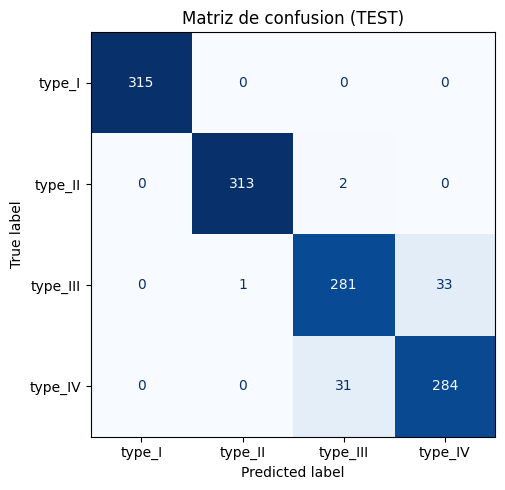


Top 15 features RF tipo_II:


,feature,importance
3,baker_sequence_ratio,0.257367
4,baker_edit_distance_norm,0.238314
7,baker_len_diff_rel,0.164058
1,baker_match_max_ratio,0.118871
2,baker_num_blocks,0.103690
0,baker_match_total_ratio,0.090134
5,baker_token_jaccard,0.026526
6,baker_common_token_coverage,0.001040


Top 20 features RF tipo_III/type_IV:


,feature,importance
3,baker_sequence_ratio,0.074799
10,baker_trigram_jaccard,0.066384
4,baker_edit_distance_norm,0.065042
0,baker_match_total_ratio,0.056084
1,baker_match_max_ratio,0.048762
9,baker_bigram_jaccard,0.047553
8,baker_lcs_ratio,0.034369
43,ast_statement_sequence_ratio,0.034037
48,ir_edit_distance_norm,0.030812
46,ir_sequence_ratio,0.030509


In [14]:
# Bloque: reporte de clasificacion y matriz de confusion.
# Las instrucciones siguientes conservan la logica funcional del modelo actual.
metricas_val = ResultadoModelo["metricas_val"]
metricas_test = ResultadoModelo["metricas_test"]

print("=== VALIDACION ===")
print("accuracy:", round(metricas_val["accuracy"], 6))
print("f1_macro:", round(metricas_val["f1_macro"], 6))

print("\n=== TEST ===")
print("accuracy:", round(metricas_test["accuracy"], 6))
print("f1_macro:", round(metricas_test["f1_macro"], 6))

reporte_test = pd.DataFrame(metricas_test["classification_report_dict"]).T
display(reporte_test)

cm = np.array(metricas_test["confusion_matrix"])
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=ETIQUETAS_MODELO).plot(cmap="Blues", ax=ax, colorbar=False)
ax.set_title("Matriz de confusion (TEST)")
plt.tight_layout()
plt.show()

print("\nTop 15 features RF tipo_II:")
display(ResultadoModelo["feature_importance_tipo_ii"].head(15))
print("Top 20 features RF tipo_III/type_IV:")
display(ResultadoModelo["feature_importance_tipo_iii_iv"].head(20))


## 12) Resultados por etapa del modelo base

**Pregunta:** como se comporta cada etapa antes de cambiar configuraciones?

**Configuracion:** se analiza el pipeline base ya entrenado.

**Metricas:** accuracy y F1 macro por etapa; en Type I se reportan precision y recall de la regla deterministica.

**Decision:** estos valores son la referencia para los experimentos.


Resumen por etapa del modelo base:


,Etapa,Datos evaluados,Accuracy_o_precision,F1_o_recall,Notas
0,Type I deterministico,1260,1.000000,1.000000,"Aciertos=315, falsos positivos=0, no detectados=0"
1,RF Type II,945,0.996825,0.996426,type_II contra resto no Type I
2,RF Type III/IV,630,0.898413,0.898412,type_III contra type_IV
3,Pipeline global 4 clases,1260,0.946825,0.946862,resultado jerarquico completo


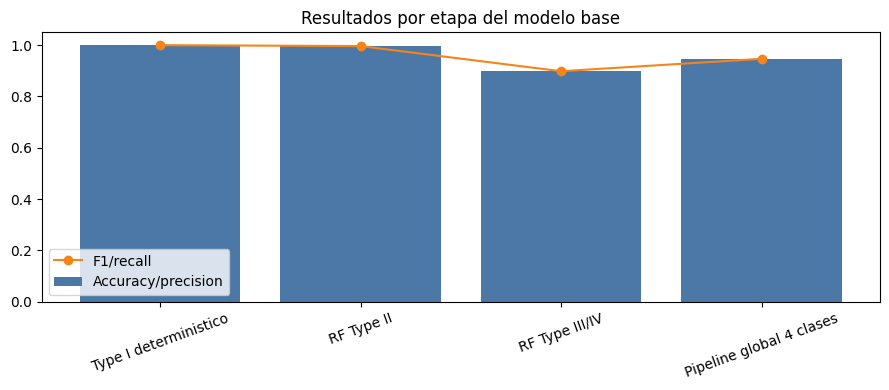

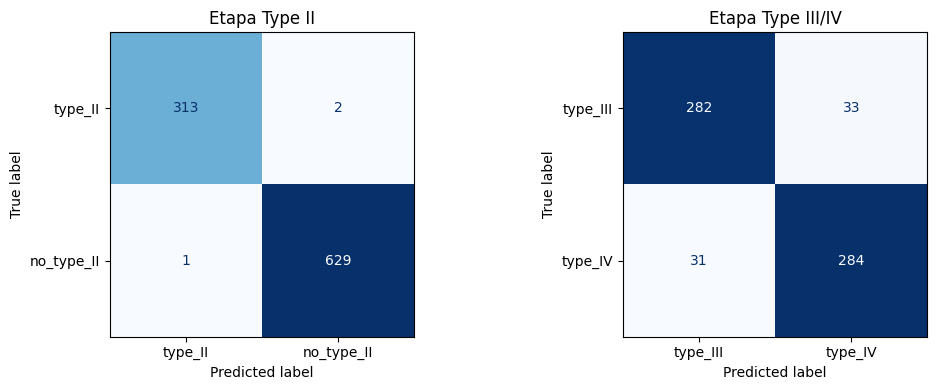

In [15]:

DatosTestBase = DatosModelo[DatosModelo["split"] == "test"].copy()
MascaraPredTipoI = detectar_tipo_i_deterministico(DatosTestBase, umbral=UMBRAL_TIPO_I)
MascaraRealTipoI = DatosTestBase["clone_type"].eq("type_I")
AciertosTipoI = int((MascaraPredTipoI & MascaraRealTipoI).sum())
FalsosTipoI = int((MascaraPredTipoI & ~MascaraRealTipoI).sum())
NoDetectadosTipoI = int((~MascaraPredTipoI & MascaraRealTipoI).sum())
PrecisionTipoI = AciertosTipoI / max(1, int(MascaraPredTipoI.sum()))
RecallTipoI = AciertosTipoI / max(1, int(MascaraRealTipoI.sum()))

IndiceNoTipoITest = DatosTestBase.index[~MascaraPredTipoI]
DatosTestNoTipoI = DatosTestBase.loc[IndiceNoTipoITest]
XTestTipoII = construir_features_tipo_ii(DatosTestNoTipoI, MIN_MATCH_LEN_BAKER)
YTestTipoII = DatosTestNoTipoI["clone_type"].eq("type_II").astype(int)
ProbTestTipoII = ResultadoModelo["modelo_tipo_ii"].predict_proba(XTestTipoII)[:, 1]
PredTestTipoII = (ProbTestTipoII >= UMBRAL_PROB_TIPO_II).astype(int)
AccuracyTipoII = accuracy_score(YTestTipoII, PredTestTipoII)
F1TipoII = f1_score(YTestTipoII, PredTestTipoII, average="macro", zero_division=0)

DatosTestT34 = DatosTestBase[DatosTestBase["clone_type"].isin(["type_III", "type_IV"])].copy()
XTestT34 = construir_features_tipo_iii_iv(DatosTestT34, MIN_MATCH_LEN_BAKER, AST_VARIANT_OFICIAL)
YTestT34 = DatosTestT34["clone_type"]
PredTestT34 = ResultadoModelo["modelo_tipo_iii_iv"].predict(XTestT34)
AccuracyT34 = accuracy_score(YTestT34, PredTestT34)
F1T34 = f1_score(YTestT34, PredTestT34, average="macro", zero_division=0)

TablaEtapasBase = pd.DataFrame([
    {"Etapa": "Type I deterministico", "Datos evaluados": len(DatosTestBase), "Accuracy_o_precision": PrecisionTipoI, "F1_o_recall": RecallTipoI, "Notas": f"Aciertos={AciertosTipoI}, falsos positivos={FalsosTipoI}, no detectados={NoDetectadosTipoI}"},
    {"Etapa": "RF Type II", "Datos evaluados": len(DatosTestNoTipoI), "Accuracy_o_precision": AccuracyTipoII, "F1_o_recall": F1TipoII, "Notas": "type_II contra resto no Type I"},
    {"Etapa": "RF Type III/IV", "Datos evaluados": len(DatosTestT34), "Accuracy_o_precision": AccuracyT34, "F1_o_recall": F1T34, "Notas": "type_III contra type_IV"},
    {"Etapa": "Pipeline global 4 clases", "Datos evaluados": len(DatosTestBase), "Accuracy_o_precision": ResultadoModelo["metricas_test"]["accuracy"], "F1_o_recall": ResultadoModelo["metricas_test"]["f1_macro"], "Notas": "resultado jerarquico completo"},
])
print("Resumen por etapa del modelo base:")
display(TablaEtapasBase.round(6))

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(TablaEtapasBase["Etapa"], TablaEtapasBase["Accuracy_o_precision"], label="Accuracy/precision", color="#4c78a8")
ax.plot(TablaEtapasBase["Etapa"], TablaEtapasBase["F1_o_recall"], marker="o", color="#f58518", label="F1/recall")
ax.set_ylim(0, 1.05)
ax.set_title("Resultados por etapa del modelo base")
ax.tick_params(axis="x", rotation=20)
ax.legend()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay.from_predictions(YTestTipoII, PredTestTipoII, labels=[1, 0], display_labels=["type_II", "no_type_II"], cmap="Blues", ax=axes[0], colorbar=False)
axes[0].set_title("Etapa Type II")
ConfusionMatrixDisplay.from_predictions(YTestT34, PredTestT34, labels=["type_III", "type_IV"], cmap="Blues", ax=axes[1], colorbar=False)
axes[1].set_title("Etapa Type III/IV")
plt.tight_layout()
plt.show()


## 12.1) Uso de datos por etapa

**Que se va a hacer:** mostrar cuantos pares usa cada etapa del pipeline en entrenamiento, validacion y prueba.

**Datos usados:** `DatosModelo`, la regla deterministica `type_I`, el RF de `type_II` ya entrenado y las etiquetas reales para identificar los pares `type_III/type_IV` durante entrenamiento.

**Salida esperada:** una tabla y una grafica. Esta seccion explica por que no todas las etapas ven los mismos ejemplos: el pipeline es jerarquico y cada etapa filtra casos para la siguiente.


Uso de datos por etapa del pipeline:


,split,Etapa,num_pares,nota
0,train,Regla deterministica type_I,5880,NaN
1,train,RF type_II,4408,NaN
2,train,RF type_III/type_IV,2940,pares reales type_III/type_IV usados para entr...
3,val,Regla deterministica type_I,1260,NaN
4,val,RF type_II,945,NaN
5,val,RF type_III/type_IV,627,pares que pasan a RF3 despues de no ser type_I...
6,test,Regla deterministica type_I,1260,NaN
7,test,RF type_II,945,NaN
8,test,RF type_III/type_IV,631,pares que pasan a RF3 despues de no ser type_I...


Etapa,RF type_II,RF type_III/type_IV,Regla deterministica type_I
split,,,
train,4408,2940,5880
val,945,627,1260
test,945,631,1260


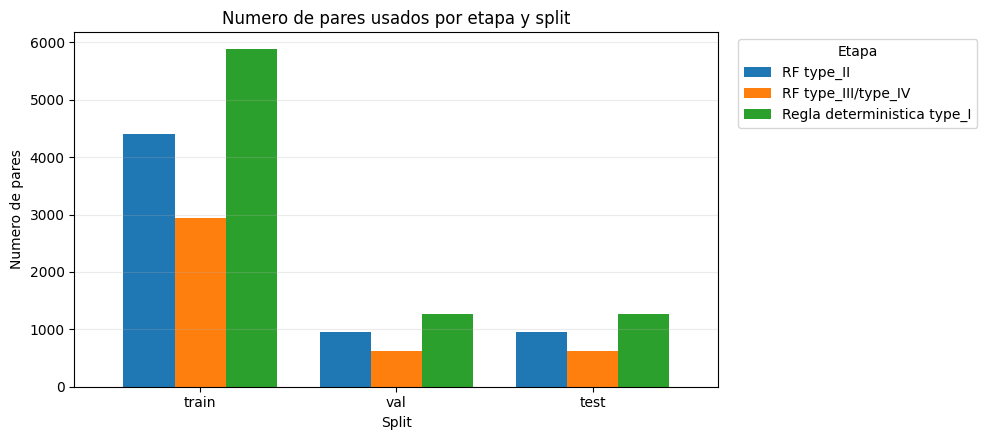

In [16]:

# Esta funcion resume el flujo de datos por etapa sin reentrenar ningun modelo.
def calcular_uso_por_etapa(df: pd.DataFrame, nombre_split: str) -> list[dict[str, object]]:
    # La regla Type I se aplica a todos los pares del split.
    MascaraTipoI = detectar_tipo_i_deterministico(df, umbral=UMBRAL_TIPO_I)
    IndicesNoTipoI = df.index[~MascaraTipoI]
    Filas = [{"split": nombre_split, "Etapa": "Regla deterministica type_I", "num_pares": len(df)}]

    # RF Type II solo recibe los pares que no fueron clasificados como Type I.
    Filas.append({"split": nombre_split, "Etapa": "RF type_II", "num_pares": len(IndicesNoTipoI)})

    # En train se entrena RF3 con ejemplos reales T3/T4; en val/test se estima cuantos llegan despues de RF2.
    if nombre_split == "train":
        NumT34 = int(df.loc[IndicesNoTipoI, "clone_type"].isin(["type_III", "type_IV"]).sum())
        Nota = "pares reales type_III/type_IV usados para entrenar RF3"
    else:
        if len(IndicesNoTipoI) == 0:
            NumT34 = 0
        else:
            XTipoII = construir_features_tipo_ii(df.loc[IndicesNoTipoI], min_match_len=MIN_MATCH_LEN_BAKER)
            ProbTipoII = ResultadoModelo["modelo_tipo_ii"].predict_proba(XTipoII)[:, 1]
            NumT34 = int((ProbTipoII < UMBRAL_PROB_TIPO_II).sum())
        Nota = "pares que pasan a RF3 despues de no ser type_I ni type_II"
    Filas.append({"split": nombre_split, "Etapa": "RF type_III/type_IV", "num_pares": NumT34, "nota": Nota})
    return Filas

# Se calcula el uso de datos en los tres splits principales.
FilasUsoEtapas = []
for NombreSplit in ["train", "val", "test"]:
    DatosSplit = DatosModelo[DatosModelo["split"] == NombreSplit].copy()
    FilasUsoEtapas.extend(calcular_uso_por_etapa(DatosSplit, NombreSplit))
TablaUsoEtapas = pd.DataFrame(FilasUsoEtapas)
print("Uso de datos por etapa del pipeline:")
display(TablaUsoEtapas)

# Tabla visual en formato ancho para explicar rapidamente el flujo de datos.
UsoEtapasPivot = TablaUsoEtapas.pivot_table(index="split", columns="Etapa", values="num_pares", aggfunc="sum", fill_value=0).reindex(index=["train", "val", "test"])
display(UsoEtapasPivot)

fig, ax = plt.subplots(figsize=(10, 4.5))
UsoEtapasPivot.plot(kind="bar", ax=ax, width=0.78)
ax.set_title("Numero de pares usados por etapa y split")
ax.set_xlabel("Split")
ax.set_ylabel("Numero de pares")
ax.tick_params(axis="x", rotation=0)
ax.grid(axis="y", alpha=0.25)
ax.legend(title="Etapa", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## 13) Experimento 1: ablation study por grupos de features

**Pregunta:** que grupo de caracteristicas aporta mas para separar `type_III` y `type_IV`?

**Configuracion:** se compara Baker base/completo para `type_II` y varias combinaciones para `type_III/type_IV`.

**Metricas:** accuracy de validacion como principal y F1 macro como respaldo.

**Decision:** la mejor combinacion por validacion pasa como candidata final.


Ablation Type II:


,Experimento,Num_features,Accuracy_val,F1_macro_val
0,Baker base 8,8,0.996825,0.996437
1,Baker completo 15,15,0.996825,0.996437


Ablation Type III/IV:


,Experimento,Grupos,Num_features,Accuracy_val,F1_macro_val
6,Baker + AST + flujo,Baker+AST+Flujo,56,0.901587,0.901552
3,Baker + AST,Baker+AST,46,0.898413,0.898376
7,Baker + AST + flujo + IR,Baker+AST+Flujo+IR,61,0.898413,0.898363
8,Baker + AST + flujo + IR + complejidad,Baker+AST+IR+Flujo+Complejidad,77,0.896825,0.896794
4,Baker + flujo,Baker+Flujo,25,0.885714,0.885673
0,Solo Baker,Baker,15,0.880952,0.880928
1,Solo AST,AST,31,0.868254,0.868179
5,AST + flujo,AST+Flujo,41,0.865079,0.864957
2,Solo flujo,Flujo,10,0.769841,0.769794


Mejor combinacion por validacion: Baker + AST + flujo


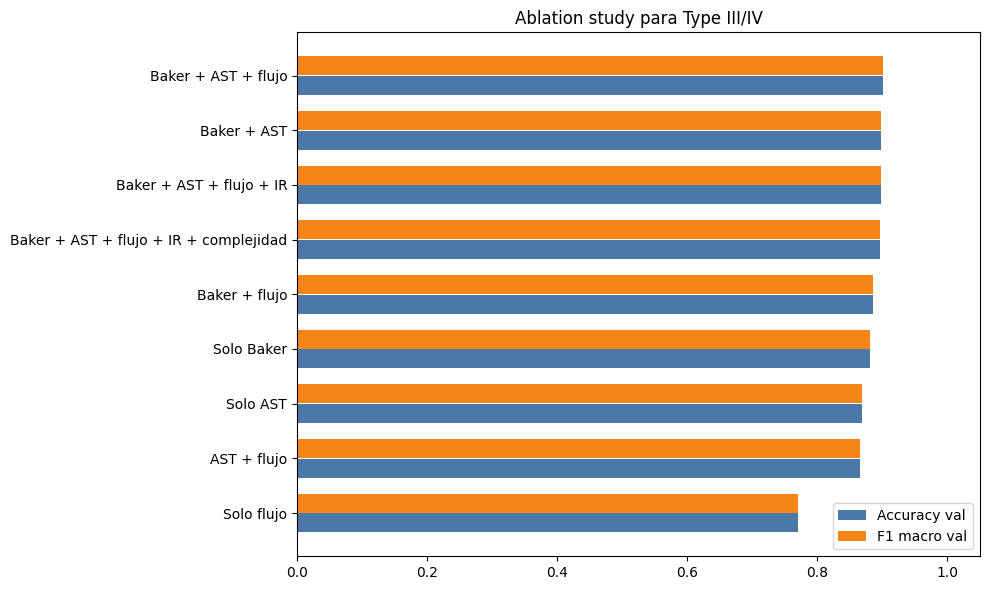

In [17]:

DatosTrainBase = DatosModelo[DatosModelo["split"] == "train"].copy()
DatosValBase = DatosModelo[DatosModelo["split"] == "val"].copy()
MascaraITrain = detectar_tipo_i_deterministico(DatosTrainBase, UMBRAL_TIPO_I)
MascaraIVal = detectar_tipo_i_deterministico(DatosValBase, UMBRAL_TIPO_I)
DatosTrainNoI = DatosTrainBase.loc[~MascaraITrain].copy()
DatosValNoI = DatosValBase.loc[~MascaraIVal].copy()
YTrainTipoII = DatosTrainNoI["clone_type"].eq("type_II").astype(int)
YValTipoII = DatosValNoI["clone_type"].eq("type_II").astype(int)

MatricesTipoII = {
    "Baker base 8": (construir_features_tipo_ii(DatosTrainNoI, MIN_MATCH_LEN_BAKER), construir_features_tipo_ii(DatosValNoI, MIN_MATCH_LEN_BAKER)),
    "Baker completo 15": (construir_features_baker(DatosTrainNoI, MIN_MATCH_LEN_BAKER), construir_features_baker(DatosValNoI, MIN_MATCH_LEN_BAKER)),
}
ResultadosAblationTipoII = []
ModelosAblationTipoII = {}
for Nombre, (XTrainT2Exp, XValT2Exp) in MatricesTipoII.items():
    ModeloT2Exp = _crear_rf(ResultadoModelo["cfg_tipo_ii"], random_state=SEED + len(Nombre))
    ModeloT2Exp.fit(XTrainT2Exp, YTrainTipoII)
    PredValT2Exp = ModeloT2Exp.predict(XValT2Exp)
    ResultadosAblationTipoII.append({"Experimento": Nombre, "Num_features": XTrainT2Exp.shape[1], "Accuracy_val": accuracy_score(YValTipoII, PredValT2Exp), "F1_macro_val": f1_score(YValTipoII, PredValT2Exp, average="macro", zero_division=0)})
    ModelosAblationTipoII[Nombre] = ModeloT2Exp
TablaAblationTipoII = pd.DataFrame(ResultadosAblationTipoII).sort_values(["Accuracy_val", "F1_macro_val"], ascending=False)
print("Ablation Type II:")
display(TablaAblationTipoII.round(6))

DatosTrainT34 = DatosTrainBase[DatosTrainBase["clone_type"].isin(["type_III", "type_IV"])].copy()
DatosValT34 = DatosValBase[DatosValBase["clone_type"].isin(["type_III", "type_IV"])].copy()
YTrainT34 = DatosTrainT34["clone_type"]
YValT34 = DatosValT34["clone_type"]
GruposTrainT34 = construir_grupos_features_t34(DatosTrainT34)
GruposValT34 = construir_grupos_features_t34(DatosValT34)
CombinacionesT34 = [
    ("Solo Baker", ["Baker"]), ("Solo AST", ["AST"]), ("Solo flujo", ["Flujo"]),
    ("Baker + AST", ["Baker", "AST"]), ("Baker + flujo", ["Baker", "Flujo"]), ("AST + flujo", ["AST", "Flujo"]),
    ("Baker + AST + flujo", ["Baker", "AST", "Flujo"]),
    ("Baker + AST + flujo + IR", ["Baker", "AST", "Flujo", "IR"]),
    ("Baker + AST + flujo + IR + complejidad", ["Baker", "AST", "IR", "Flujo", "Complejidad"]),
]
ResultadosAblationT34 = []
ModelosAblationT34 = {}
for Nombre, Grupos in CombinacionesT34:
    XTrainT34Exp = combinar_grupos_features(GruposTrainT34, Grupos)
    XValT34Exp = combinar_grupos_features(GruposValT34, Grupos)
    ModeloT34Exp = _crear_rf(ResultadoModelo["cfg_tipo_iii_iv"], random_state=SEED + 200 + len(ResultadosAblationT34))
    ModeloT34Exp.fit(XTrainT34Exp, YTrainT34)
    PredValT34Exp = ModeloT34Exp.predict(XValT34Exp)
    ResultadosAblationT34.append({"Experimento": Nombre, "Grupos": "+".join(Grupos), "Num_features": XTrainT34Exp.shape[1], "Accuracy_val": accuracy_score(YValT34, PredValT34Exp), "F1_macro_val": f1_score(YValT34, PredValT34Exp, average="macro", zero_division=0)})
    ModelosAblationT34[Nombre] = {"modelo": ModeloT34Exp, "grupos": Grupos, "columnas": list(XTrainT34Exp.columns)}
TablaAblationT34 = pd.DataFrame(ResultadosAblationT34).sort_values(["Accuracy_val", "F1_macro_val"], ascending=False)
MejorAblationT34 = TablaAblationT34.iloc[0].to_dict()
print("Ablation Type III/IV:")
display(TablaAblationT34.round(6))
print("Mejor combinacion por validacion:", MejorAblationT34["Experimento"])

TablaPlot = TablaAblationT34.sort_values("Accuracy_val")
fig, ax = plt.subplots(figsize=(10, 6))
y = np.arange(len(TablaPlot))
ax.barh(y - 0.18, TablaPlot["Accuracy_val"], height=0.35, label="Accuracy val", color="#4c78a8")
ax.barh(y + 0.18, TablaPlot["F1_macro_val"], height=0.35, label="F1 macro val", color="#f58518")
ax.set_yticks(y)
ax.set_yticklabels(TablaPlot["Experimento"])
ax.set_xlim(0, 1.05)
ax.set_title("Ablation study para Type III/IV")
ax.legend()
plt.tight_layout()
plt.show()


## 14) Experimento 2: ajuste de umbral para Type II

**Pregunta:** el umbral de probabilidad de RF2 cambia el desempeno global del pipeline?

**Configuracion:** se prueban umbrales de `0.30` a `0.70` usando validacion. Type I queda fijo en `1.0`.

**Metricas:** accuracy global, F1 macro global y cantidad predicha como `type_II`.

**Decision:** se elige el mejor umbral por accuracy de validacion y F1 macro como respaldo.


Resultados por umbral Type II:


,Umbral_RF_Tipo_II,Predichos_type_II,Accuracy_val,F1_macro_val
0,0.30,318,0.952381,0.95228
1,0.35,318,0.952381,0.95228
2,0.40,318,0.952381,0.95228
3,0.45,318,0.952381,0.95228
4,0.50,318,0.952381,0.95228
5,0.55,318,0.952381,0.95228
6,0.60,318,0.952381,0.95228
7,0.65,317,0.951587,0.95153
8,0.70,316,0.950794,0.95078


Mejor umbral seleccionado por validacion: 0.3


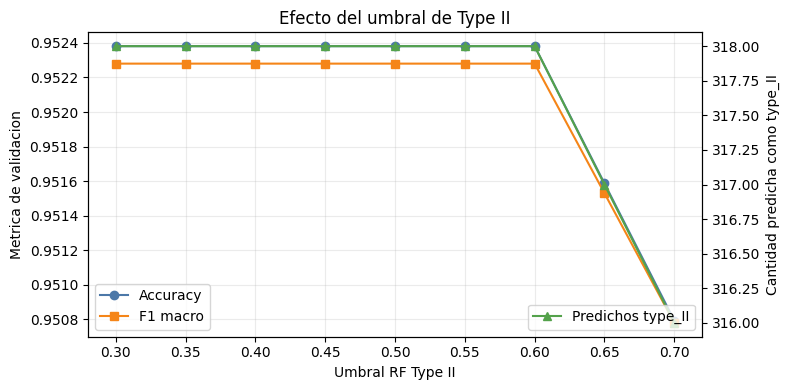

In [18]:

DatosValUmbral = DatosModelo[DatosModelo["split"] == "val"].copy()
MascaraTipoIVal = detectar_tipo_i_deterministico(DatosValUmbral, umbral=UMBRAL_TIPO_I)
IndiceRFVal = DatosValUmbral.index[~MascaraTipoIVal]
XTipoIIVal = construir_features_tipo_ii(DatosValUmbral.loc[IndiceRFVal], MIN_MATCH_LEN_BAKER)
ProbTipoIIVal = ResultadoModelo["modelo_tipo_ii"].predict_proba(XTipoIIVal)[:, 1]
XT34ValActual = construir_features_tipo_iii_iv(DatosValUmbral.loc[IndiceRFVal], MIN_MATCH_LEN_BAKER, AST_VARIANT_OFICIAL)
PredT34ValActual = pd.Series(ResultadoModelo["modelo_tipo_iii_iv"].predict(XT34ValActual), index=IndiceRFVal)
ResultadosUmbral = []
for UmbralTipoII in [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]:
    HipotesisVal = pd.Series(index=DatosValUmbral.index, dtype="object")
    HipotesisVal.loc[MascaraTipoIVal] = "type_I"
    MascaraAceptadaT2 = ProbTipoIIVal >= UmbralTipoII
    HipotesisVal.loc[IndiceRFVal[MascaraAceptadaT2]] = "type_II"
    IndicePasaT34 = IndiceRFVal[~MascaraAceptadaT2]
    HipotesisVal.loc[IndicePasaT34] = PredT34ValActual.loc[IndicePasaT34]
    MetricasUmbral = evaluar_predicciones(DatosValUmbral["clone_type"], HipotesisVal, ETIQUETAS_MODELO)
    ResultadosUmbral.append({"Umbral_RF_Tipo_II": UmbralTipoII, "Predichos_type_II": int((HipotesisVal == "type_II").sum()), "Accuracy_val": MetricasUmbral["accuracy"], "F1_macro_val": MetricasUmbral["f1_macro"]})
TablaUmbrales = pd.DataFrame(ResultadosUmbral).sort_values(["Accuracy_val", "F1_macro_val"], ascending=False)
MejorUmbralTipoII = float(TablaUmbrales.iloc[0]["Umbral_RF_Tipo_II"])
print("Resultados por umbral Type II:")
display(TablaUmbrales.round(6))
print("Mejor umbral seleccionado por validacion:", MejorUmbralTipoII)
TablaUmbralesOrden = TablaUmbrales.sort_values("Umbral_RF_Tipo_II")
fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(TablaUmbralesOrden["Umbral_RF_Tipo_II"], TablaUmbralesOrden["Accuracy_val"], marker="o", label="Accuracy", color="#4c78a8")
ax1.plot(TablaUmbralesOrden["Umbral_RF_Tipo_II"], TablaUmbralesOrden["F1_macro_val"], marker="s", label="F1 macro", color="#f58518")
ax1.set_xlabel("Umbral RF Type II")
ax1.set_ylabel("Metrica de validacion")
ax1.set_title("Efecto del umbral de Type II")
ax1.grid(alpha=0.25)
ax1.legend(loc="lower left")
ax2 = ax1.twinx()
ax2.plot(TablaUmbralesOrden["Umbral_RF_Tipo_II"], TablaUmbralesOrden["Predichos_type_II"], marker="^", color="#54a24b", label="Predichos type_II")
ax2.set_ylabel("Cantidad predicha como type_II")
ax2.legend(loc="lower right")
plt.tight_layout()
plt.show()


## 15) Experimento 3: Decision Tree contra Random Forest

**Pregunta:** un arbol de decision simple reduce costo sin perder demasiado desempeno?

**Configuracion:** se prueban profundidades `5, 10, 15, 20, 30, None` para Type II y Type III/IV, y se compara contra Random Forest base.

**Metricas:** accuracy, F1 macro, tiempo de entrenamiento y tiempo de prediccion.

**Decision:** Random Forest se justifica si mejora claramente el desempeno frente al costo adicional.


Decision Tree vs Random Forest:


,Modelo,Etapa,Accuracy_val,F1_macro_val,Tiempo_train_s,Tiempo_pred_s,Profundidad
6,RandomForest_base,Type II,0.996825,0.996437,2.052328,0.105895,NaN
1,DecisionTree_depth_10,Type II,0.994709,0.994071,0.007116,0.001065,10.0
2,DecisionTree_depth_15,Type II,0.994709,0.994071,0.006977,0.000813,15.0
3,DecisionTree_depth_20,Type II,0.994709,0.994071,0.007134,0.000761,20.0
4,DecisionTree_depth_30,Type II,0.994709,0.994071,0.007125,0.001137,30.0
5,DecisionTree_depth_None,Type II,0.994709,0.994071,0.006980,0.000754,NaN
0,DecisionTree_depth_5,Type II,0.994709,0.994062,0.007354,0.000856,5.0
13,RandomForest_base,Type III/IV,0.900000,0.899970,3.007435,0.151085,NaN
8,DecisionTree_depth_10,Type III/IV,0.844444,0.844444,0.081105,0.001688,10.0
9,DecisionTree_depth_15,Type III/IV,0.838095,0.838036,0.092543,0.001734,15.0


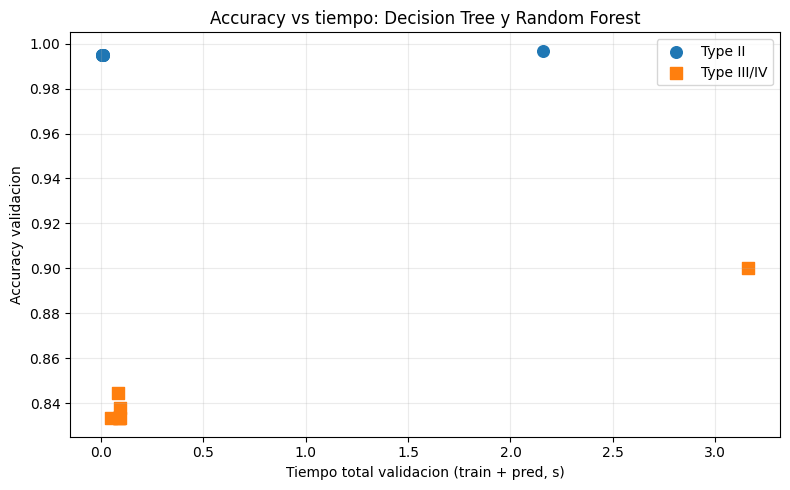

In [19]:

XTrainT2Base = construir_features_tipo_ii(DatosTrainNoI, MIN_MATCH_LEN_BAKER)
XValT2Base = construir_features_tipo_ii(DatosValNoI, MIN_MATCH_LEN_BAKER)
XTrainT34Full = combinar_grupos_features(GruposTrainT34, ["Baker", "AST", "IR", "Flujo", "Complejidad"])
XValT34Full = combinar_grupos_features(GruposValT34, ["Baker", "AST", "IR", "Flujo", "Complejidad"])

def medir_modelo_supervisado(nombre: str, etapa: str, modelo, X_train, y_train, X_val, y_val) -> dict[str, object]:
    inicio_train = time.perf_counter()
    modelo.fit(X_train, y_train)
    tiempo_train = time.perf_counter() - inicio_train
    inicio_pred = time.perf_counter()
    pred = modelo.predict(X_val)
    tiempo_pred = time.perf_counter() - inicio_pred
    return {"Modelo": nombre, "Etapa": etapa, "Accuracy_val": accuracy_score(y_val, pred), "F1_macro_val": f1_score(y_val, pred, average="macro", zero_division=0), "Tiempo_train_s": tiempo_train, "Tiempo_pred_s": tiempo_pred, "modelo_obj": modelo}

ResultadosArbolVsRF = []
ModelosArbolVsRF = {}
for Etapa, XTrain, YTrain, XVal, YVal in [("Type II", XTrainT2Base, YTrainTipoII, XValT2Base, YValTipoII), ("Type III/IV", XTrainT34Full, YTrainT34, XValT34Full, YValT34)]:
    for Profundidad in [5, 10, 15, 20, 30, None]:
        Nombre = f"DecisionTree_depth_{Profundidad}"
        Resultado = medir_modelo_supervisado(Nombre, Etapa, DecisionTreeClassifier(max_depth=Profundidad, class_weight="balanced", random_state=SEED), XTrain, YTrain, XVal, YVal)
        Clave = f"{Etapa}_{Nombre}"
        ModelosArbolVsRF[Clave] = Resultado.pop("modelo_obj")
        Resultado.update({"Profundidad": Profundidad, "Clave": Clave})
        ResultadosArbolVsRF.append(Resultado)
    ConfigBase = ResultadoModelo["cfg_tipo_ii"] if Etapa == "Type II" else ResultadoModelo["cfg_tipo_iii_iv"]
    Resultado = medir_modelo_supervisado("RandomForest_base", Etapa, _crear_rf(ConfigBase, random_state=SEED + 300 + len(ResultadosArbolVsRF)), XTrain, YTrain, XVal, YVal)
    Clave = f"{Etapa}_RandomForest_base"
    ModelosArbolVsRF[Clave] = Resultado.pop("modelo_obj")
    Resultado.update({"Profundidad": ConfigBase.max_depth, "Clave": Clave})
    ResultadosArbolVsRF.append(Resultado)
TablaArbolVsRF = pd.DataFrame(ResultadosArbolVsRF).sort_values(["Etapa", "Accuracy_val", "F1_macro_val"], ascending=[True, False, False])
print("Decision Tree vs Random Forest:")
display(TablaArbolVsRF.drop(columns=["Clave"]).round(6))
MejorDT_T2 = TablaArbolVsRF[(TablaArbolVsRF["Etapa"] == "Type II") & (TablaArbolVsRF["Modelo"].str.startswith("DecisionTree"))].iloc[0]
MejorDT_T34 = TablaArbolVsRF[(TablaArbolVsRF["Etapa"] == "Type III/IV") & (TablaArbolVsRF["Modelo"].str.startswith("DecisionTree"))].iloc[0]
MejorDT_T2_Modelo = ModelosArbolVsRF[MejorDT_T2["Clave"]]
MejorDT_T34_Modelo = ModelosArbolVsRF[MejorDT_T34["Clave"]]
fig, ax = plt.subplots(figsize=(8, 5))
for Etapa, Marcador in [("Type II", "o"), ("Type III/IV", "s")]:
    Sub = TablaArbolVsRF[TablaArbolVsRF["Etapa"] == Etapa]
    ax.scatter(Sub["Tiempo_train_s"] + Sub["Tiempo_pred_s"], Sub["Accuracy_val"], label=Etapa, marker=Marcador, s=70)
ax.set_xlabel("Tiempo total validacion (train + pred, s)")
ax.set_ylabel("Accuracy validacion")
ax.set_title("Accuracy vs tiempo: Decision Tree y Random Forest")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()


## 16) Experimento 4: Random Forest con numero de arboles y poda

**Pregunta:** se puede mejorar Random Forest ajustando arboles, profundidad y poda sin hacer una busqueda excesiva?

**Configuracion:** busqueda controlada sobre `n_estimators`, `max_depth`, `min_samples_leaf` y `min_samples_split`.

**Metricas:** accuracy, F1 macro, tiempo de entrenamiento y prediccion en validacion.

**Decision:** se selecciona por accuracy de validacion; ante empate se prefiere el mas rapido o simple.


Busqueda controlada de Random Forest:


,Modelo,Etapa,Accuracy_val,F1_macro_val,Tiempo_train_s,Tiempo_pred_s,n_estimators,max_depth,min_samples_leaf,min_samples_split,max_features
0,RandomForest_opt,Type II,0.996825,0.996437,0.443533,0.030657,100,NaN,1,2,sqrt
1,RandomForest_opt,Type II,0.996825,0.996437,1.263255,0.071104,300,NaN,1,2,sqrt
12,RandomForest_opt,Type II,0.996825,0.996437,2.096949,0.106585,500,NaN,1,5,sqrt
2,RandomForest_opt,Type II,0.996825,0.996437,2.118494,0.105144,500,NaN,1,2,sqrt
9,RandomForest_opt,Type II,0.996825,0.996437,2.128948,0.114171,500,30.0,1,2,sqrt
8,RandomForest_opt,Type II,0.996825,0.996437,2.498753,0.115527,500,20.0,1,2,sqrt
7,RandomForest_opt,Type II,0.996825,0.996437,2.514356,0.129460,500,10.0,1,2,sqrt
3,RandomForest_opt,Type II,0.996825,0.996437,3.035154,0.156499,700,NaN,1,2,sqrt
4,RandomForest_opt,Type II,0.996825,0.996437,3.362638,0.167585,800,NaN,1,2,sqrt
5,RandomForest_opt,Type II,0.996825,0.996437,5.010610,0.265537,900,NaN,1,2,sqrt


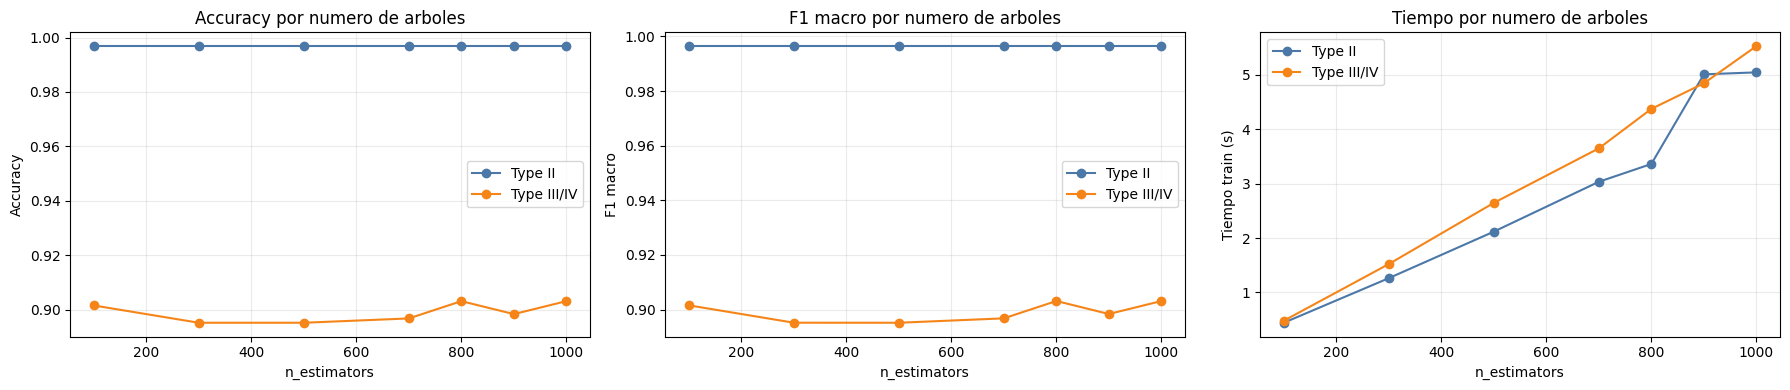

In [20]:

def configuraciones_rf_controladas() -> list[ConfigRF]:
    configs = []
    for n in [100, 300, 500, 700, 800, 900, 1000]: configs.append(ConfigRF(n, None, 1, 2, "sqrt"))
    for profundidad in [10, 20, 30, None]: configs.append(ConfigRF(500, profundidad, 1, 2, "sqrt"))
    for hoja in [1, 2, 5]: configs.append(ConfigRF(500, None, hoja, 2, "sqrt"))
    for split in [2, 5, 10]: configs.append(ConfigRF(500, None, 1, split, "sqrt"))
    vistos, unicos = set(), []
    for cfg in configs:
        clave = (cfg.n_estimators, cfg.max_depth, cfg.min_samples_leaf, cfg.min_samples_split, cfg.max_features)
        if clave not in vistos:
            vistos.add(clave); unicos.append(cfg)
    return unicos

ResultadosRFOpt = []
ModelosRFOpt = {}
for Etapa, XTrain, YTrain, XVal, YVal in [("Type II", XTrainT2Base, YTrainTipoII, XValT2Base, YValTipoII), ("Type III/IV", XTrainT34Full, YTrainT34, XValT34Full, YValT34)]:
    for i, cfg in enumerate(configuraciones_rf_controladas()):
        Resultado = medir_modelo_supervisado("RandomForest_opt", Etapa, _crear_rf(cfg, random_state=SEED + 500 + i), XTrain, YTrain, XVal, YVal)
        Clave = f"RFOPT_{Etapa}_{i}"
        ModelosRFOpt[Clave] = Resultado.pop("modelo_obj")
        Resultado.update({"Clave": Clave, "n_estimators": cfg.n_estimators, "max_depth": cfg.max_depth, "min_samples_leaf": cfg.min_samples_leaf, "min_samples_split": cfg.min_samples_split, "max_features": cfg.max_features})
        ResultadosRFOpt.append(Resultado)
TablaRFOpt = pd.DataFrame(ResultadosRFOpt).sort_values(["Etapa", "Accuracy_val", "F1_macro_val", "Tiempo_train_s"], ascending=[True, False, False, True])
print("Busqueda controlada de Random Forest:")
display(TablaRFOpt.drop(columns=["Clave"]).round(6))
MejorRF_T2 = TablaRFOpt[TablaRFOpt["Etapa"] == "Type II"].iloc[0]
MejorRF_T34 = TablaRFOpt[TablaRFOpt["Etapa"] == "Type III/IV"].iloc[0]
MejorRF_T2_Modelo = ModelosRFOpt[MejorRF_T2["Clave"]]
MejorRF_T34_Modelo = ModelosRFOpt[MejorRF_T34["Clave"]]
MejorRF_T2_Config = ConfigRF(int(MejorRF_T2["n_estimators"]), None if pd.isna(MejorRF_T2["max_depth"]) else int(MejorRF_T2["max_depth"]), int(MejorRF_T2["min_samples_leaf"]), int(MejorRF_T2["min_samples_split"]), "sqrt")
MejorRF_T34_Config = ConfigRF(int(MejorRF_T34["n_estimators"]), None if pd.isna(MejorRF_T34["max_depth"]) else int(MejorRF_T34["max_depth"]), int(MejorRF_T34["min_samples_leaf"]), int(MejorRF_T34["min_samples_split"]), "sqrt")
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for Etapa, Color in [("Type II", "#4c78a8"), ("Type III/IV", "#f58518")]:
    SubN = TablaRFOpt[(TablaRFOpt["Etapa"] == Etapa) & (TablaRFOpt["max_depth"].isna()) & (TablaRFOpt["min_samples_leaf"].eq(1)) & (TablaRFOpt["min_samples_split"].eq(2))].sort_values("n_estimators")
    axes[0].plot(SubN["n_estimators"], SubN["Accuracy_val"], marker="o", label=Etapa, color=Color)
    axes[1].plot(SubN["n_estimators"], SubN["F1_macro_val"], marker="o", label=Etapa, color=Color)
    axes[2].plot(SubN["n_estimators"], SubN["Tiempo_train_s"], marker="o", label=Etapa, color=Color)
for ax in axes:
    ax.set_xlabel("n_estimators"); ax.grid(alpha=0.25); ax.legend()
axes[0].set_title("Accuracy por numero de arboles"); axes[0].set_ylabel("Accuracy")
axes[1].set_title("F1 macro por numero de arboles"); axes[1].set_ylabel("F1 macro")
axes[2].set_title("Tiempo por numero de arboles"); axes[2].set_ylabel("Tiempo train (s)")
plt.tight_layout(); plt.show()


## 17) Experimento 5: importancia de features y reduccion

**Pregunta:** se pueden retirar features con poca importancia sin perder desempeno?

**Configuracion:** se usa el mejor RF de `type_III/type_IV` y se prueban variantes: completo, sin importancia menor a `0.5%`, top 20, top 30 y acumulado 90%.

**Metricas:** accuracy, F1 macro, numero de features y tiempo.

**Decision:** una variante reducida pasa a candidata si mantiene o mejora validacion.


Top 20 features del mejor RF Type III/IV:


,feature,importance,grupo,importance_acumulada
3,baker_sequence_ratio,0.067948,Baker,0.067948
10,baker_trigram_jaccard,0.061733,Baker,0.129681
4,baker_edit_distance_norm,0.060522,Baker,0.190203
0,baker_match_total_ratio,0.056889,Baker,0.247092
1,baker_match_max_ratio,0.049406,Baker,0.296499
9,baker_bigram_jaccard,0.046750,Baker,0.343248
8,baker_lcs_ratio,0.042435,Baker,0.385683
43,ast_statement_sequence_ratio,0.036577,AST,0.422260
48,ir_edit_distance_norm,0.032466,IR,0.454726
40,ast_type_weighted_overlap,0.027888,AST,0.482613


Importancia por grupo:


,grupo,importance
1,Baker,0.490360
0,AST,0.259728
4,IR,0.104570
2,Complejidad,0.093143
3,Flujo,0.052200


Features candidatas a revision (<0.5%): 29


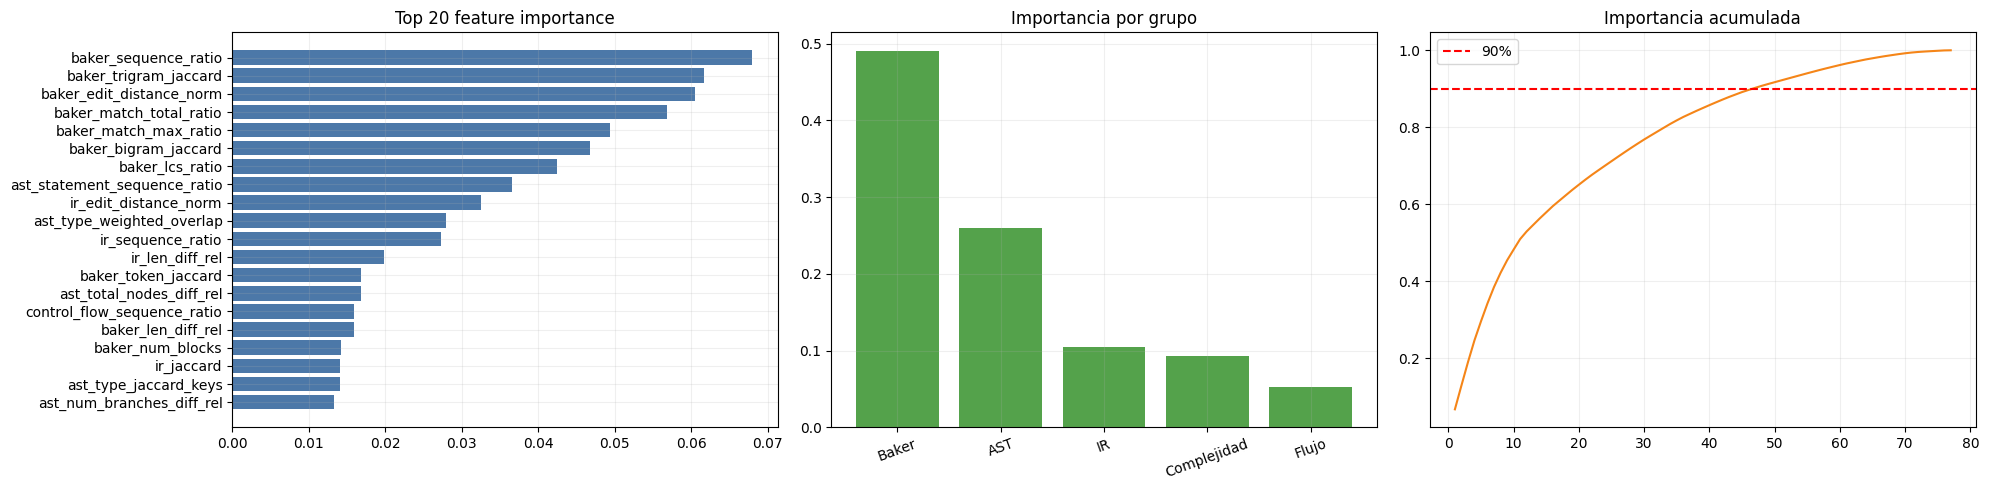

Comparacion de reduccion de features:


,Variante,Num_features,Accuracy_val,F1_macro_val,Tiempo_train_s,Tiempo_pred_s
0,Completo,77,0.906349,0.906264,4.490548,0.185593
1,Sin importancia <0.5%,48,0.898413,0.898347,4.884541,0.164383
4,Acumulado 90%,47,0.896825,0.896781,5.563616,0.220311
3,Top 30,30,0.888889,0.888798,4.295554,0.186560
2,Top 20,20,0.882540,0.882444,3.456731,0.126653


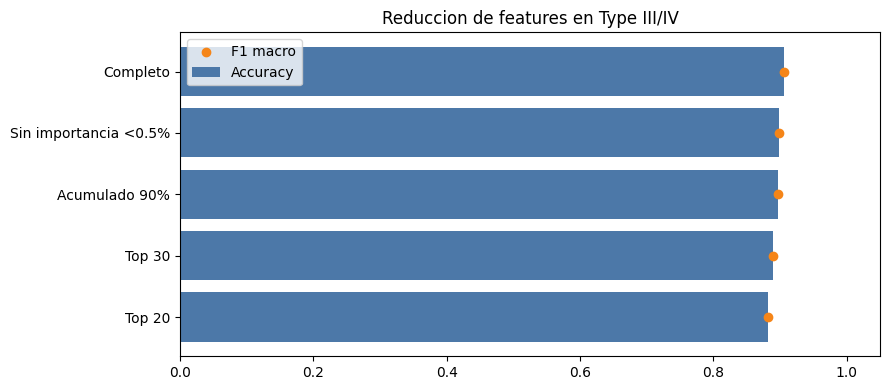

In [21]:

ImportanciasMejorT34 = pd.DataFrame({"feature": XTrainT34Full.columns, "importance": MejorRF_T34_Modelo.feature_importances_}).sort_values("importance", ascending=False)
ImportanciasMejorT34["grupo"] = ImportanciasMejorT34["feature"].map(grupo_de_feature)
ImportanciasMejorT34["importance_acumulada"] = ImportanciasMejorT34["importance"].cumsum()
ImportanciaPorGrupo = ImportanciasMejorT34.groupby("grupo", as_index=False)["importance"].sum().sort_values("importance", ascending=False)
FeaturesRevision = ImportanciasMejorT34[ImportanciasMejorT34["importance"] < 0.005].copy()
print("Top 20 features del mejor RF Type III/IV:")
display(ImportanciasMejorT34.head(20).round(6))
print("Importancia por grupo:")
display(ImportanciaPorGrupo.round(6))
print("Features candidatas a revision (<0.5%):", len(FeaturesRevision))
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
Top20 = ImportanciasMejorT34.head(20).sort_values("importance")
axes[0].barh(Top20["feature"], Top20["importance"], color="#4c78a8"); axes[0].set_title("Top 20 feature importance")
axes[1].bar(ImportanciaPorGrupo["grupo"], ImportanciaPorGrupo["importance"], color="#54a24b"); axes[1].set_title("Importancia por grupo"); axes[1].tick_params(axis="x", rotation=20)
axes[2].plot(range(1, len(ImportanciasMejorT34)+1), ImportanciasMejorT34["importance_acumulada"], color="#f58518"); axes[2].axhline(0.90, color="red", linestyle="--", label="90%"); axes[2].set_title("Importancia acumulada"); axes[2].legend()
for ax in axes: ax.grid(alpha=0.2)
plt.tight_layout(); plt.show()

ColumnasTodas = list(XTrainT34Full.columns)
ColumnasSinRelleno = ImportanciasMejorT34[ImportanciasMejorT34["importance"] >= 0.005]["feature"].tolist()
ColumnasTop20 = ImportanciasMejorT34.head(20)["feature"].tolist()
ColumnasTop30 = ImportanciasMejorT34.head(30)["feature"].tolist()
ColumnasAcum90 = ImportanciasMejorT34[ImportanciasMejorT34["importance_acumulada"] <= 0.90]["feature"].tolist()
if len(ColumnasAcum90) < len(ImportanciasMejorT34): ColumnasAcum90 = ImportanciasMejorT34.head(len(ColumnasAcum90)+1)["feature"].tolist()
VariantesReduccion = {"Completo": ColumnasTodas, "Sin importancia <0.5%": ColumnasSinRelleno, "Top 20": ColumnasTop20, "Top 30": ColumnasTop30, "Acumulado 90%": ColumnasAcum90}
ResultadosReduccion, ModelosReduccion, ColumnasReduccion = [], {}, {}
for Nombre, Columnas in VariantesReduccion.items():
    ModeloRed = _crear_rf(MejorRF_T34_Config, random_state=SEED + 900 + len(ResultadosReduccion))
    inicio_train = time.perf_counter(); ModeloRed.fit(XTrainT34Full[Columnas], YTrainT34); tiempo_train = time.perf_counter() - inicio_train
    inicio_pred = time.perf_counter(); PredValRed = ModeloRed.predict(XValT34Full[Columnas]); tiempo_pred = time.perf_counter() - inicio_pred
    ResultadosReduccion.append({"Variante": Nombre, "Num_features": len(Columnas), "Accuracy_val": accuracy_score(YValT34, PredValRed), "F1_macro_val": f1_score(YValT34, PredValRed, average="macro", zero_division=0), "Tiempo_train_s": tiempo_train, "Tiempo_pred_s": tiempo_pred})
    ModelosReduccion[Nombre] = ModeloRed; ColumnasReduccion[Nombre] = Columnas
TablaReduccion = pd.DataFrame(ResultadosReduccion).sort_values(["Accuracy_val", "F1_macro_val", "Num_features"], ascending=[False, False, True])
MejorReduccion = TablaReduccion.iloc[0]
print("Comparacion de reduccion de features:")
display(TablaReduccion.round(6))
fig, ax = plt.subplots(figsize=(9, 4))
TablaRedPlot = TablaReduccion.sort_values("Accuracy_val")
ax.barh(TablaRedPlot["Variante"], TablaRedPlot["Accuracy_val"], color="#4c78a8", label="Accuracy")
ax.scatter(TablaRedPlot["F1_macro_val"], TablaRedPlot["Variante"], color="#f58518", label="F1 macro")
ax.set_xlim(0, 1.05); ax.set_title("Reduccion de features en Type III/IV"); ax.legend()
plt.tight_layout(); plt.show()


## 18) Seleccion del modelo final

**Pregunta:** alguno de los experimentos supera al modelo base?

**Configuracion:** se evaluan candidatos completos del pipeline: base, mejor ablation, mejor umbral, mejor Decision Tree, mejor Random Forest optimizado y mejor reduccion.

**Metricas:** accuracy y F1 macro en validacion y prueba, numero de features, hiperparametros y tiempos.

**Decision:** se selecciona por accuracy de validacion; F1 macro y simplicidad resuelven empates.


Tabla de candidatos finales:


,Modelo,Features usadas,Num_features_T34,Hiperparametros,Accuracy_val,F1_macro_val,Accuracy_test,F1_macro_test,Tiempo_train_s,Tiempo_pred_val_s,Tiempo_pred_test_s
0,Modelo base actual,Baker+AST+Flujo+IR+Complejidad,77,"{'n_estimators': 600, 'max_depth': None, 'min_...",0.952381,0.952280,0.946825,0.946862,0.000000,0.317312,0.316128
2,Mejor umbral Type II,base con umbral ajustado,77,umbral_t2=0.3,0.952381,0.952280,0.946825,0.946862,0.000000,0.483174,0.526089
4,Mejor Random Forest optimizado,RF optimizado,77,"T2={'n_estimators': 100, 'max_depth': None, 'm...",0.950794,0.950692,0.943651,0.943678,3.348386,0.204887,0.164941
5,Mejor reduccion por importancia,Completo,77,"{'n_estimators': 500, 'max_depth': 20, 'min_sa...",0.950794,0.950681,0.946825,0.946862,4.490548,0.254486,0.235559
1,Mejor ablation T34,Baker+AST+Flujo,56,"{'n_estimators': 600, 'max_depth': None, 'min_...",0.948413,0.948304,0.939683,0.939716,0.000000,0.315535,0.452783
3,Mejor Decision Tree,Decision Tree en etapa 2 y 3,77,T2=DecisionTree_depth_10; T34=DecisionTree_dep...,0.918254,0.917943,0.930952,0.931005,0.088221,0.059324,0.064231


Modelo seleccionado por validacion: Modelo base actual


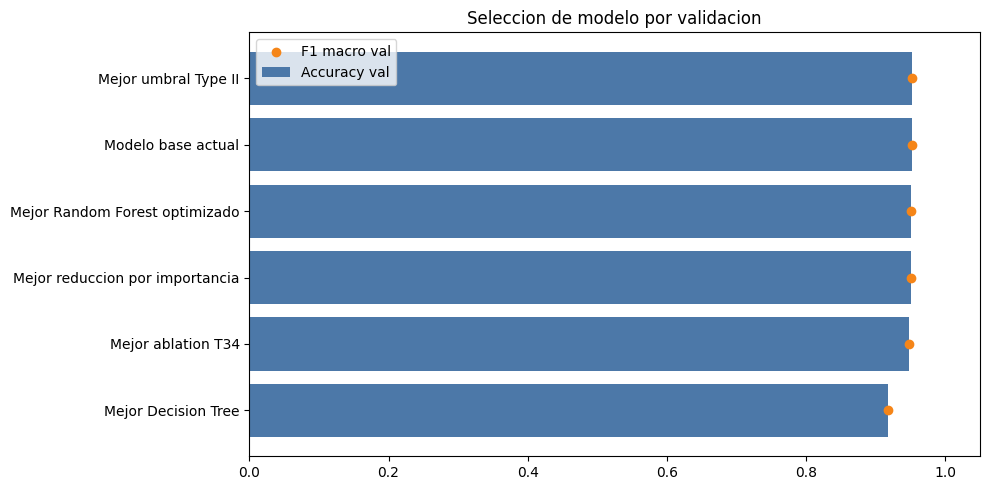

In [22]:

def preparar_cache_pipeline(df: pd.DataFrame) -> dict[str, object]:
    mascara_i = detectar_tipo_i_deterministico(df, UMBRAL_TIPO_I)
    idx_no_i = df.index[~mascara_i]
    datos_no_i = df.loc[idx_no_i].copy()
    return {"df": df, "mascara_i": mascara_i, "idx_no_i": idx_no_i, "X_t2_base": construir_features_tipo_ii(datos_no_i, MIN_MATCH_LEN_BAKER), "grupos_t34": construir_grupos_features_t34(datos_no_i)}


def evaluar_candidato_pipeline(cache: dict[str, object], modelo_t2, modelo_t34, grupos_t34: list[str], columnas_t34=None, umbral_t2: float = 0.50):
    df = cache["df"]
    hipotesis = pd.Series(index=df.index, dtype="object")
    hipotesis.loc[cache["mascara_i"]] = "type_I"
    idx_no_i = cache["idx_no_i"]
    if len(idx_no_i) > 0:
        prob_t2 = modelo_t2.predict_proba(cache["X_t2_base"])[:, 1]
        mascara_t2 = prob_t2 >= umbral_t2
        hipotesis.loc[idx_no_i[mascara_t2]] = "type_II"
        idx_t34 = idx_no_i[~mascara_t2]
        if len(idx_t34) > 0:
            X_t34_todos = combinar_grupos_features(cache["grupos_t34"], grupos_t34)
            if columnas_t34 is not None: X_t34_todos = X_t34_todos[columnas_t34]
            hipotesis.loc[idx_t34] = modelo_t34.predict(X_t34_todos.loc[idx_t34])
    hipotesis = hipotesis.fillna("type_IV")
    return hipotesis, evaluar_predicciones(df["clone_type"], hipotesis, ETIQUETAS_MODELO)

CacheVal = preparar_cache_pipeline(DatosValBase)
CacheTest = preparar_cache_pipeline(DatosTestBase)
CandidatosDef = [
    {"Modelo": "Modelo base actual", "modelo_t2": ResultadoModelo["modelo_tipo_ii"], "modelo_t34": ResultadoModelo["modelo_tipo_iii_iv"], "grupos_t34": ["Baker","AST","IR","Flujo","Complejidad"], "columnas_t34": None, "umbral": UMBRAL_PROB_TIPO_II, "features": "Baker+AST+Flujo+IR+Complejidad", "num_features": ResultadoModelo["num_features_tipo_iii_iv"], "hiper": str(ResultadoModelo["cfg_tipo_iii_iv"].__dict__), "train_s": 0.0},
    {"Modelo": "Mejor ablation T34", "modelo_t2": ResultadoModelo["modelo_tipo_ii"], "modelo_t34": ModelosAblationT34[MejorAblationT34["Experimento"]]["modelo"], "grupos_t34": ModelosAblationT34[MejorAblationT34["Experimento"]]["grupos"], "columnas_t34": None, "umbral": UMBRAL_PROB_TIPO_II, "features": MejorAblationT34["Grupos"], "num_features": int(MejorAblationT34["Num_features"]), "hiper": str(ResultadoModelo["cfg_tipo_iii_iv"].__dict__), "train_s": 0.0},
    {"Modelo": "Mejor umbral Type II", "modelo_t2": ResultadoModelo["modelo_tipo_ii"], "modelo_t34": ResultadoModelo["modelo_tipo_iii_iv"], "grupos_t34": ["Baker","AST","IR","Flujo","Complejidad"], "columnas_t34": None, "umbral": MejorUmbralTipoII, "features": "base con umbral ajustado", "num_features": ResultadoModelo["num_features_tipo_iii_iv"], "hiper": f"umbral_t2={MejorUmbralTipoII}", "train_s": 0.0},
    {"Modelo": "Mejor Decision Tree", "modelo_t2": MejorDT_T2_Modelo, "modelo_t34": MejorDT_T34_Modelo, "grupos_t34": ["Baker","AST","IR","Flujo","Complejidad"], "columnas_t34": None, "umbral": UMBRAL_PROB_TIPO_II, "features": "Decision Tree en etapa 2 y 3", "num_features": XTrainT34Full.shape[1], "hiper": f"T2={MejorDT_T2['Modelo']}; T34={MejorDT_T34['Modelo']}", "train_s": float(MejorDT_T2["Tiempo_train_s"] + MejorDT_T34["Tiempo_train_s"])},
    {"Modelo": "Mejor Random Forest optimizado", "modelo_t2": MejorRF_T2_Modelo, "modelo_t34": MejorRF_T34_Modelo, "grupos_t34": ["Baker","AST","IR","Flujo","Complejidad"], "columnas_t34": None, "umbral": UMBRAL_PROB_TIPO_II, "features": "RF optimizado", "num_features": XTrainT34Full.shape[1], "hiper": f"T2={MejorRF_T2_Config.__dict__}; T34={MejorRF_T34_Config.__dict__}", "train_s": float(MejorRF_T2["Tiempo_train_s"] + MejorRF_T34["Tiempo_train_s"])},
    {"Modelo": "Mejor reduccion por importancia", "modelo_t2": ResultadoModelo["modelo_tipo_ii"], "modelo_t34": ModelosReduccion[MejorReduccion["Variante"]], "grupos_t34": ["Baker","AST","IR","Flujo","Complejidad"], "columnas_t34": ColumnasReduccion[MejorReduccion["Variante"]], "umbral": UMBRAL_PROB_TIPO_II, "features": MejorReduccion["Variante"], "num_features": int(MejorReduccion["Num_features"]), "hiper": str(MejorRF_T34_Config.__dict__), "train_s": float(MejorReduccion["Tiempo_train_s"])}]

FilasCandidatos, PrediccionesCandidatosTest, MetricasCandidatosTest = [], {}, {}
for C in CandidatosDef:
    inicio_val = time.perf_counter(); PredVal, MetVal = evaluar_candidato_pipeline(CacheVal, C["modelo_t2"], C["modelo_t34"], C["grupos_t34"], C["columnas_t34"], C["umbral"]); pred_val_s = time.perf_counter()-inicio_val
    inicio_test = time.perf_counter(); PredTest, MetTest = evaluar_candidato_pipeline(CacheTest, C["modelo_t2"], C["modelo_t34"], C["grupos_t34"], C["columnas_t34"], C["umbral"]); pred_test_s = time.perf_counter()-inicio_test
    PrediccionesCandidatosTest[C["Modelo"]] = PredTest; MetricasCandidatosTest[C["Modelo"]] = MetTest
    FilasCandidatos.append({"Modelo": C["Modelo"], "Features usadas": C["features"], "Num_features_T34": C["num_features"], "Hiperparametros": C["hiper"], "Accuracy_val": MetVal["accuracy"], "F1_macro_val": MetVal["f1_macro"], "Accuracy_test": MetTest["accuracy"], "F1_macro_test": MetTest["f1_macro"], "Tiempo_train_s": C["train_s"], "Tiempo_pred_val_s": pred_val_s, "Tiempo_pred_test_s": pred_test_s})
TablaSeleccionFinal = pd.DataFrame(FilasCandidatos).sort_values(["Accuracy_val", "F1_macro_val", "Tiempo_train_s"], ascending=[False, False, True])
ModeloFinalSeleccionado = TablaSeleccionFinal.iloc[0]["Modelo"]
print("Tabla de candidatos finales:")
display(TablaSeleccionFinal.round(6))
print("Modelo seleccionado por validacion:", ModeloFinalSeleccionado)
fig, ax = plt.subplots(figsize=(10, 5))
TablaSelPlot = TablaSeleccionFinal.sort_values("Accuracy_val")
ax.barh(TablaSelPlot["Modelo"], TablaSelPlot["Accuracy_val"], color="#4c78a8", label="Accuracy val")
ax.scatter(TablaSelPlot["F1_macro_val"], TablaSelPlot["Modelo"], color="#f58518", label="F1 macro val")
ax.set_xlim(0, 1.05); ax.set_title("Seleccion de modelo por validacion"); ax.legend()
plt.tight_layout(); plt.show()


## 19) Evaluacion final del modelo seleccionado

**Pregunta:** el modelo seleccionado mantiene buen comportamiento en prueba?

**Configuracion:** se reportan metricas globales, metricas por clase, matriz de confusion y comparacion contra el modelo base.

**Metricas:** accuracy principal, F1 macro secundario, precision, recall y soporte por clase.

**Decision:** se documenta si el modelo seleccionado reemplaza al base o si se conserva el base.


Modelo final seleccionado: Modelo base actual
Accuracy test: 0.946825
F1 macro test: 0.946862


,precision,recall,f1-score,support
type_I,1.000000,1.000000,1.000000,315.000000
type_II,0.996815,0.993651,0.995231,315.000000
type_III,0.894904,0.892063,0.893482,315.000000
type_IV,0.895899,0.901587,0.898734,315.000000
accuracy,0.946825,0.946825,0.946825,0.946825
macro avg,0.946905,0.946825,0.946862,1260.000000
weighted avg,0.946905,0.946825,0.946862,1260.000000


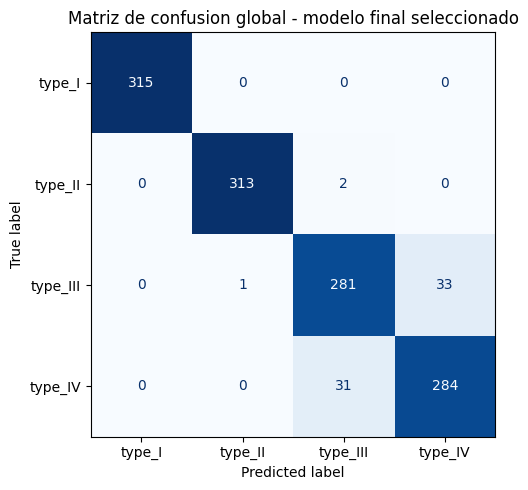

Comparacion base contra modelo seleccionado:


,Modelo,Accuracy_test,F1_macro_test
0,Base anterior,0.946825,0.946862
1,Modelo base actual,0.946825,0.946862


Decision: se conserva el modelo base porque ningun experimento mejora su validacion de forma suficiente.


In [23]:

PredFinalTest = PrediccionesCandidatosTest[ModeloFinalSeleccionado]
MetricasFinalTest = MetricasCandidatosTest[ModeloFinalSeleccionado]
ReporteFinalTest = pd.DataFrame(MetricasFinalTest["classification_report_dict"]).T
print("Modelo final seleccionado:", ModeloFinalSeleccionado)
print("Accuracy test:", round(MetricasFinalTest["accuracy"], 6))
print("F1 macro test:", round(MetricasFinalTest["f1_macro"], 6))
display(ReporteFinalTest.round(6))
cm_final = confusion_matrix(DatosTestBase["clone_type"], PredFinalTest, labels=ETIQUETAS_MODELO)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm_final, display_labels=ETIQUETAS_MODELO).plot(cmap="Blues", ax=ax, colorbar=False)
ax.set_title("Matriz de confusion global - modelo final seleccionado")
plt.tight_layout(); plt.show()
TablaBaseVsFinal = pd.DataFrame([
    {"Modelo": "Base anterior", "Accuracy_test": ResultadoModelo["metricas_test"]["accuracy"], "F1_macro_test": ResultadoModelo["metricas_test"]["f1_macro"]},
    {"Modelo": ModeloFinalSeleccionado, "Accuracy_test": MetricasFinalTest["accuracy"], "F1_macro_test": MetricasFinalTest["f1_macro"]},
])
print("Comparacion base contra modelo seleccionado:")
display(TablaBaseVsFinal.round(6))
if ModeloFinalSeleccionado == "Modelo base actual":
    print("Decision: se conserva el modelo base porque ningun experimento mejora su validacion de forma suficiente.")
else:
    print("Decision: el modelo seleccionado reemplaza al base como candidato final, segun accuracy de validacion y confirmacion en test.")


## 20) Cierre del experimento

El notebook ahora muestra el experimento completo dentro del mismo archivo:

* comportamiento por etapa;
* aporte de grupos de features;
* efecto del umbral de `type_II`;
* Decision Tree vs Random Forest;
* efecto de numero de arboles, profundidad y poda;
* importancia de features y reduccion;
* seleccion final por validacion y confirmacion en test.

Todas las salidas se muestran con `display()` o `plt.show()` dentro del notebook. No se guardan reportes, imagenes ni archivos externos.
